# 1.0 Imports

In [126]:
import pandas as pd
import numpy as np

from scipy import stats as ss
from IPython.display import Image
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as mt

import seaborn as sns
import matplotlib.pyplot as plt
import optuna

# Funções

In [2]:
#função para analise multivariada categórica
def cramer_v( x, y ): 
    cm = pd.crosstab( x, y ).values
    n = cm.sum() 
    r, k = cm.shape 
    chi2 = ss.chi2_contingency( cm )[0] 
    chi2corr = max( 0, chi2 - (k-1)*(r-1)/(n-1) ) 
    kcorr = k - (k-1)**2/(n-1) 
    rcorr = r - (r-1)**2/(n-1) 

    return np.sqrt((chi2corr/n)/( min( kcorr-1, rcorr-1)))

# 2.0 Carregando os dados

In [3]:
df = pd.read_excel('/home/lucas/projetos/churn_IBM/dataset/Telco_customer_churn.xlsx')

# 3.0 Verificando os dados

In [4]:
#.T transpõe linhas e colunas
df.head().T

,0,1,2,3,4
CustomerID,3668-QPYBK,9237-HQITU,9305-CDSKC,7892-POOKP,0280-XJGEX
Count,1,1,1,1,1
Country,United States,United States,United States,United States,United States
State,California,California,California,California,California
City,Los Angeles,Los Angeles,Los Angeles,Los Angeles,Los Angeles
Zip Code,90003,90005,90006,90010,90015
Lat Long,"33.964131, -118.272783","34.059281, -118.30742","34.048013, -118.293953","34.062125, -118.315709","34.039224, -118.266293"
Latitude,33.964131,34.059281,34.048013,34.062125,34.039224
Longitude,-118.272783,-118.30742,-118.293953,-118.315709,-118.266293
Gender,Male,Female,Female,Female,Male


# 4.0 Discrição dos dados

In [5]:
df1 = df.copy()

#### 4.1 Dimensões

In [6]:
print(f'O número de linhas é {df1.shape[0]}')
print(f'O número de colunas é {df1.shape[1]}')

O número de linhas é 7043
O número de colunas é 33


In [7]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

#### 4.2 Data Types

In [8]:
#passa o types e ainda me fala os NULL
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

#### 4.3 Check NA

In [9]:
df1.isna().sum()

#churn reason tem bastante, porque nem todo mundo responde sobre a saída da emrpresa

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

#### 4.4 Check Duplicatas

In [10]:
df1.duplicated().sum()

#aqui mostra que tinha valores em "branco". O que não permitiu passar objetic para float via astype
aux_7 = (df1['Total Charges'] == ' ').sum()
aux_7

np.int64(11)

#### 4.5 Analise Descritiva

In [11]:
#trocar objetic em float64
df1['Total Charges'] = pd.to_numeric(df1['Total Charges'], errors='coerce').fillna(0)


#separando as variáveis categórcas e numéricas para anlise
num_attributes = df1.select_dtypes(include = ['int64', 'float64'])

cat_attributes = df1.select_dtypes(exclude = ['int64', 'float64'])


In [12]:
#mostrando que onde tem 0 no total charges é devido o Tenure ser 0 também. (total charges = tenure months x monthly charges )
X = df1.loc[df1['Total Charges'] == 0, :]
X.T


,2234,2438,2568,2667,2856,4331,4687,5104,5719,6772,6840
CustomerID,4472-LVYGI,3115-CZMZD,5709-LVOEQ,4367-NUYAO,1371-DWPAZ,7644-OMVMY,3213-VVOLG,2520-SGTTA,2923-ARZLG,4075-WKNIU,2775-SEFEE
Count,1,1,1,1,1,1,1,1,1,1,1
Country,United States,United States,United States,United States,United States,United States,United States,United States,United States,United States,United States
State,California,California,California,California,California,California,California,California,California,California,California
City,San Bernardino,Independence,San Mateo,Cupertino,Redcrest,Los Angeles,Sun City,Ben Lomond,La Verne,Bell,Wilmington
Zip Code,92408,93526,94401,95014,95569,90029,92585,95005,91750,90201,90744
Lat Long,"34.084909, -117.258107","36.869584, -118.189241","37.590421, -122.306467","37.306612, -122.080621","40.363446, -123.835041","34.089953, -118.294824","33.739412, -117.173334","37.078873, -122.090386","34.144703, -117.770299","33.970343, -118.171368","33.782068, -118.262263"
Latitude,34.084909,36.869584,37.590421,37.306612,40.363446,34.089953,33.739412,37.078873,34.144703,33.970343,33.782068
Longitude,-117.258107,-118.189241,-122.306467,-122.080621,-123.835041,-118.294824,-117.173334,-122.090386,-117.770299,-118.171368,-118.262263
Gender,Female,Male,Female,Male,Female,Male,Male,Female,Male,Female,Male


In [13]:
print(cat_attributes.head().T)

                                              0                      1  \
CustomerID                           3668-QPYBK             9237-HQITU   
Country                           United States          United States   
State                                California             California   
City                                Los Angeles            Los Angeles   
Lat Long                 33.964131, -118.272783  34.059281, -118.30742   
Gender                                     Male                 Female   
Senior Citizen                               No                     No   
Partner                                      No                     No   
Dependents                                   No                    Yes   
Phone Service                               Yes                    Yes   
Multiple Lines                               No                     No   
Internet Service                            DSL            Fiber optic   
Online Security                       

In [14]:
num_attributes = num_attributes.drop(['Zip Code'], axis = 1)
print(num_attributes.head().T)

                           0            1            2            3  \
Count               1.000000     1.000000     1.000000     1.000000   
Latitude           33.964131    34.059281    34.048013    34.062125   
Longitude        -118.272783  -118.307420  -118.293953  -118.315709   
Tenure Months       2.000000     2.000000     8.000000    28.000000   
Monthly Charges    53.850000    70.700000    99.650000   104.800000   
Total Charges     108.150000   151.650000   820.500000  3046.050000   
Churn Value         1.000000     1.000000     1.000000     1.000000   
Churn Score        86.000000    67.000000    86.000000    84.000000   
CLTV             3239.000000  2701.000000  5372.000000  5003.000000   

                           4  
Count               1.000000  
Latitude           34.039224  
Longitude        -118.266293  
Tenure Months      49.000000  
Monthly Charges   103.700000  
Total Charges    5036.300000  
Churn Value         1.000000  
Churn Score        89.000000  
CLTV      

In [15]:
#traz mais informações dos dados com describe
cat_attributes.describe().T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"33.964131, -118.272783",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [16]:
num_attributes.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Total Charges,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550000,3786.600000,8684.800000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


#### 4.5.1 Variáveis numéricas

In [17]:
#tendencia central - média e mediana

ct1 = pd.DataFrame(num_attributes.mean()).T

ct2 = pd.DataFrame(num_attributes.median()).T

#dispersão: std, minimo, maximo, range, skewness, kurtosis

d1 = pd.DataFrame(num_attributes.std()).T
d2 = pd.DataFrame(num_attributes.min()).T
d3 = pd.DataFrame(num_attributes.max()).T
d4 = pd.DataFrame(num_attributes.max() - num_attributes.min()).T
d5 = pd.DataFrame(num_attributes.skew()).T
d6 = pd.DataFrame(num_attributes.kurtosis()).T

#outras formas de calcular
#d7 = num_attributes.apply(np.ptp)
#d8 = num_attributes.std()
#d1 = pd.DataFrame.std(num_attributes).T

#concatenar os resultados
m = pd.concat([ct1, ct2, d1, d2, d3, d4, d5, d6]).T.reset_index()
m.columns = ['attributes', 'mean', 'median', 'std', 'min', 'max', 'range', 'skew', 'kurtosis']
m

#-0.5 a 0.5: pouco assimetria
#-1 a -0,5: assimetrica moderadamente
#0.5 a 1: assimetrica moderadamente
#-1 < e > 1: assimetria forte

,attributes,mean,median,std,min,max,range,skew,kurtosis
0,Count,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
1,Latitude,36.282441,36.391777,2.455723,32.555828,41.962127,9.406299,0.303867,-1.135607
2,Longitude,-119.798880,-119.730885,2.157889,-124.301372,-114.192901,10.108471,-0.040792,-1.136050
3,Tenure Months,32.371149,29.000000,24.559481,0.000000,72.000000,72.000000,0.239540,-1.387372
4,Monthly Charges,64.761692,70.350000,30.090047,18.250000,118.750000,100.500000,-0.220524,-1.257260
5,Total Charges,2279.734304,1394.550000,2266.794470,0.000000,8684.800000,8684.800000,0.963235,-0.228580
6,Churn Value,0.265370,0.000000,0.441561,0.000000,1.000000,1.000000,1.063031,-0.870211
7,Churn Score,58.699418,61.000000,21.525131,5.000000,100.000000,95.000000,-0.089840,-1.005679
8,CLTV,4400.295755,4527.000000,1183.057152,2003.000000,6500.000000,4497.000000,-0.311602,-0.934032


#### 4.5.2 Variáveis categóricas

In [18]:
ct3 = cat_attributes.nunique()
ct3

CustomerID           7043
Country                 1
State                   1
City                 1129
Lat Long             1652
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Churn Label             2
Churn Reason           20
dtype: int64

#### 4.5.3 Corrigindo variáveis categóricas

In [19]:
#onde é Yes ou No, tinha 3 resposta, deixando apenas Yes ou No 


#cat_attributes['Multiple Lines'] = cat_attributes['Multiple Lines'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Online Security'] = cat_attributes['Online Security'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Online Backup'] = cat_attributes['Online Backup'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Device Protection'] = cat_attributes['Device Protection'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Tech Support'] = cat_attributes['Tech Support'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Streaming TV'] = cat_attributes['Streaming TV'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Streaming Movies'] = cat_attributes['Streaming Movies'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')

features = ['Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

for i in features:
    cat_attributes[i] = cat_attributes[i].apply(lambda x: 'Yes' if x == 'Yes' else 'No')


cat_attributes.nunique()


#cat_attributes['Multiple Lines'].unique()

CustomerID           7043
Country                 1
State                   1
City                 1129
Lat Long             1652
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Phone Service           2
Multiple Lines          2
Internet Service        3
Online Security         2
Online Backup           2
Device Protection       2
Tech Support            2
Streaming TV            2
Streaming Movies        2
Contract                3
Paperless Billing       2
Payment Method          4
Churn Label             2
Churn Reason           20
dtype: int64

In [20]:
num_attributes.groupby('Monthly Charges').nunique()

,Count,Latitude,Longitude,Tenure Months,Total Charges,Churn Value,Churn Score,CLTV
Monthly Charges,,,,,,,,
18.25,1,1,1,1,1,1,1,1
18.40,1,1,1,1,1,1,1,1
18.55,1,1,1,1,1,1,1,1
18.70,1,2,2,2,2,1,2,2
18.75,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...
118.20,1,1,1,1,1,1,1,1
118.35,1,1,1,1,1,1,1,1
118.60,1,2,2,2,2,1,2,2


# 5.0 Mapa Mental

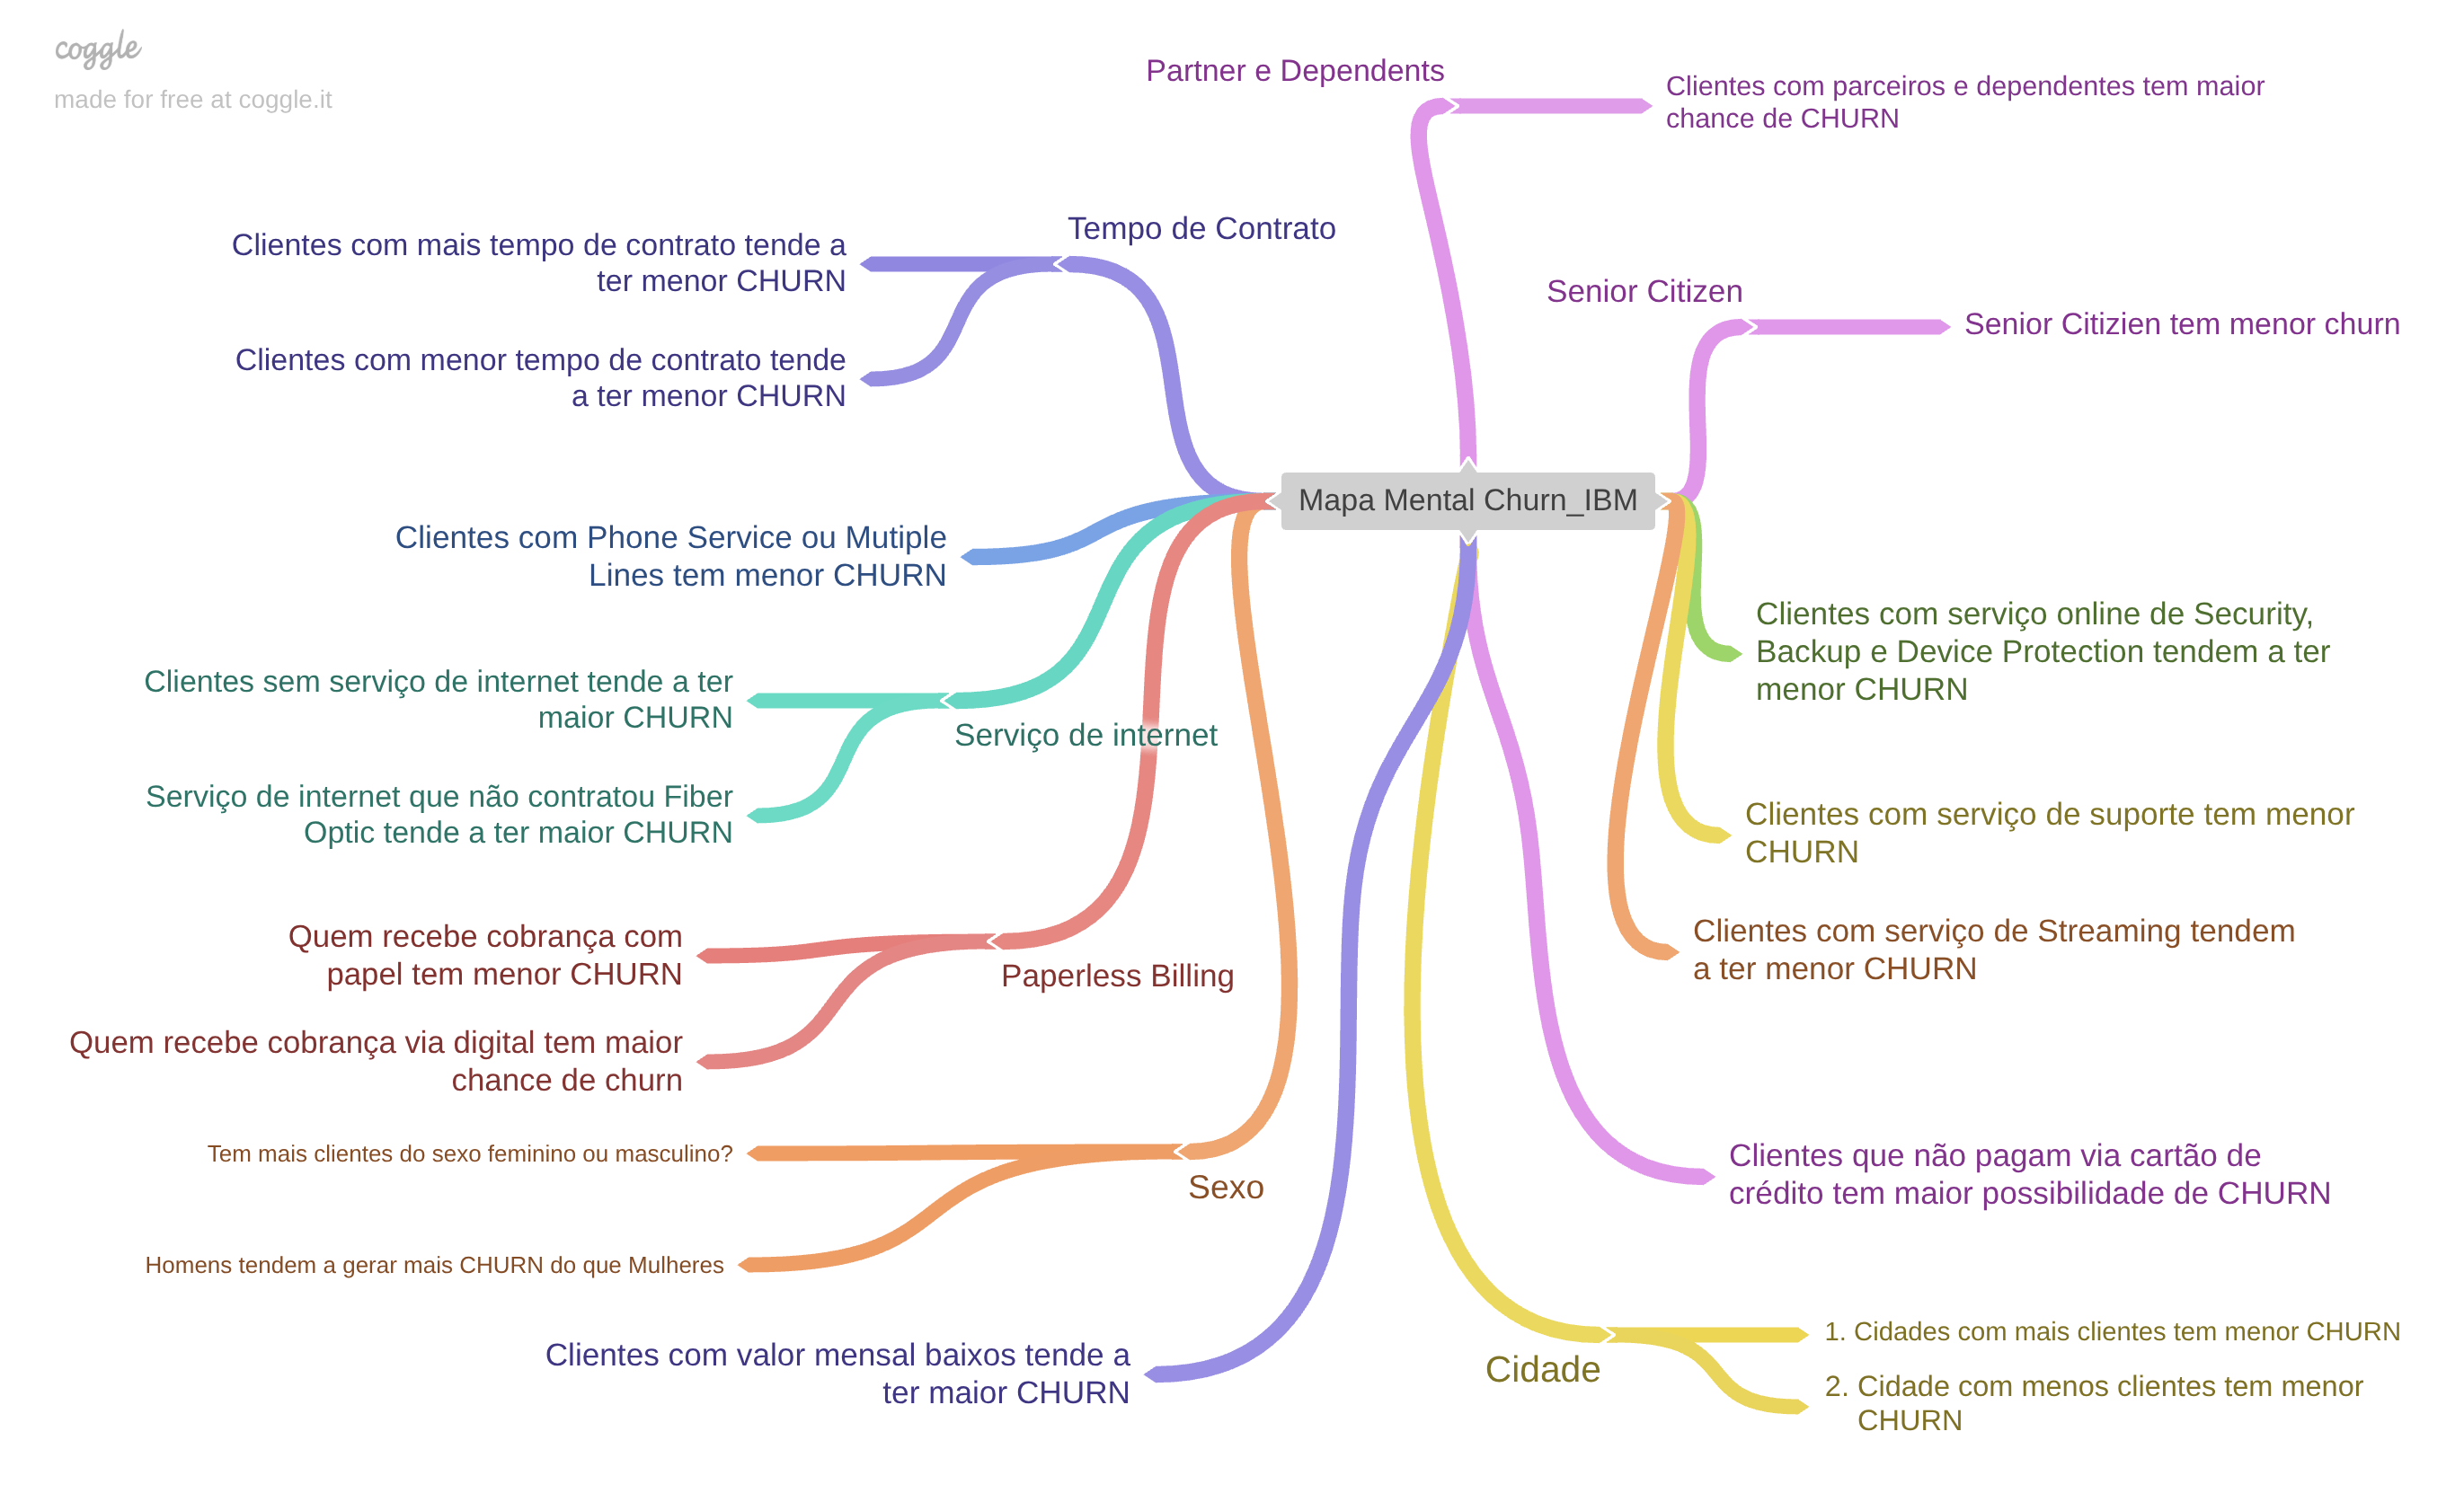

In [21]:
Image('imagens/Mapa_Mental_Churn_IBM.png')

#### 5.1 Criação de Hipoteses

#### 5.2 Hipóteses:

- Clientes com parceiros e dependentes tem maior chance de CHURN
- Senior Citizien tem menor CHURN
- Clientes com serviço online de Security, Backup e Device Protection tendem a ter menor CHURN
- Clientes com serviço de suporte tem menor CHURN
- Clientes com serviço de Streaming tendem a ter menor CHURN
- Clientes que não pagam via cartão de crédito tem maior possibilidade de CHURN
- Cidade:
    - Cidades com mais clientes tem menor CHURN
    - Cidade com menos clientes tem menor CHURN
- Clientes com valor mensal baixos tende a ter maior CHURN
- Sexo:
    - Homens tendem a gerar mais CHURN do que Mulheres
    - Tem mais clientes do sexo feminino ou masculino?
- Paperless Billing:
    - Quem recebe cobrança via digital tem maior chance de churn
    - Quem recebe cobrança com papel tem menor CHURN
- Serviço de internet:
    - Serviço de internet que não contratou Fiber Optic tende a ter maior CHURN
    - Clientes sem serviço de internet tende a ter maior CHURN
- Clientes com Phone Service ou Mutiple Lines tem menor CHURN
- Tempo De Contrato:
    - Clientes com menor tempo de contrato tende a ter menor CHURN
    - Clientes com mais tempo de contrato tende a ter menor CHURN


# 6.0 Feature Engineering

In [22]:
df2 = df.copy()

In [23]:
features = ['Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

for i in features:
    df2[i] = df2[i].apply(lambda x: 'Yes' if x == 'Yes' else 'No')


df2['Churn Value'] = df2['Churn Value'].apply(lambda x: 'No' if x == 0 else 'Yes')



# 7.0 Filtragem de Variáveis

In [24]:
df3 = df2.copy()

df3 = df3.drop(['CustomerID', 'Count', 'Lat Long'], axis = 1)

df3.shape[1]

30

# 8.0 E.D.A

### 8.1 Análise Univariada

#### 8.1.1 Variável Resposta

Churn Value
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


<Axes: xlabel='Churn Value', ylabel='Count'>

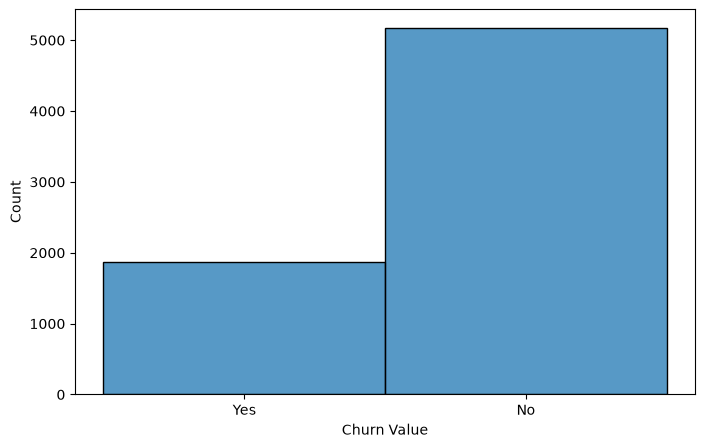

In [25]:
#aqui contabiliza os valores de yes e no, normalize coloca como proporção
df3['Churn Value'].value_counts(normalize = True)
print(df3['Churn Value'].value_counts(normalize = True))

plt.figure(figsize = (8, 5))

#é onde está passando o gráfico de Churn Value
sns.histplot(df3['Churn Value'])

#### 8.1.2 Variáveis Numéricas

array([[<Axes: title={'center': 'Count'}>,
        <Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>],
       [<Axes: title={'center': 'Tenure Months'}>,
        <Axes: title={'center': 'Monthly Charges'}>,
        <Axes: title={'center': 'Total Charges'}>],
       [<Axes: title={'center': 'Churn Value'}>,
        <Axes: title={'center': 'Churn Score'}>,
        <Axes: title={'center': 'CLTV'}>]], dtype=object)

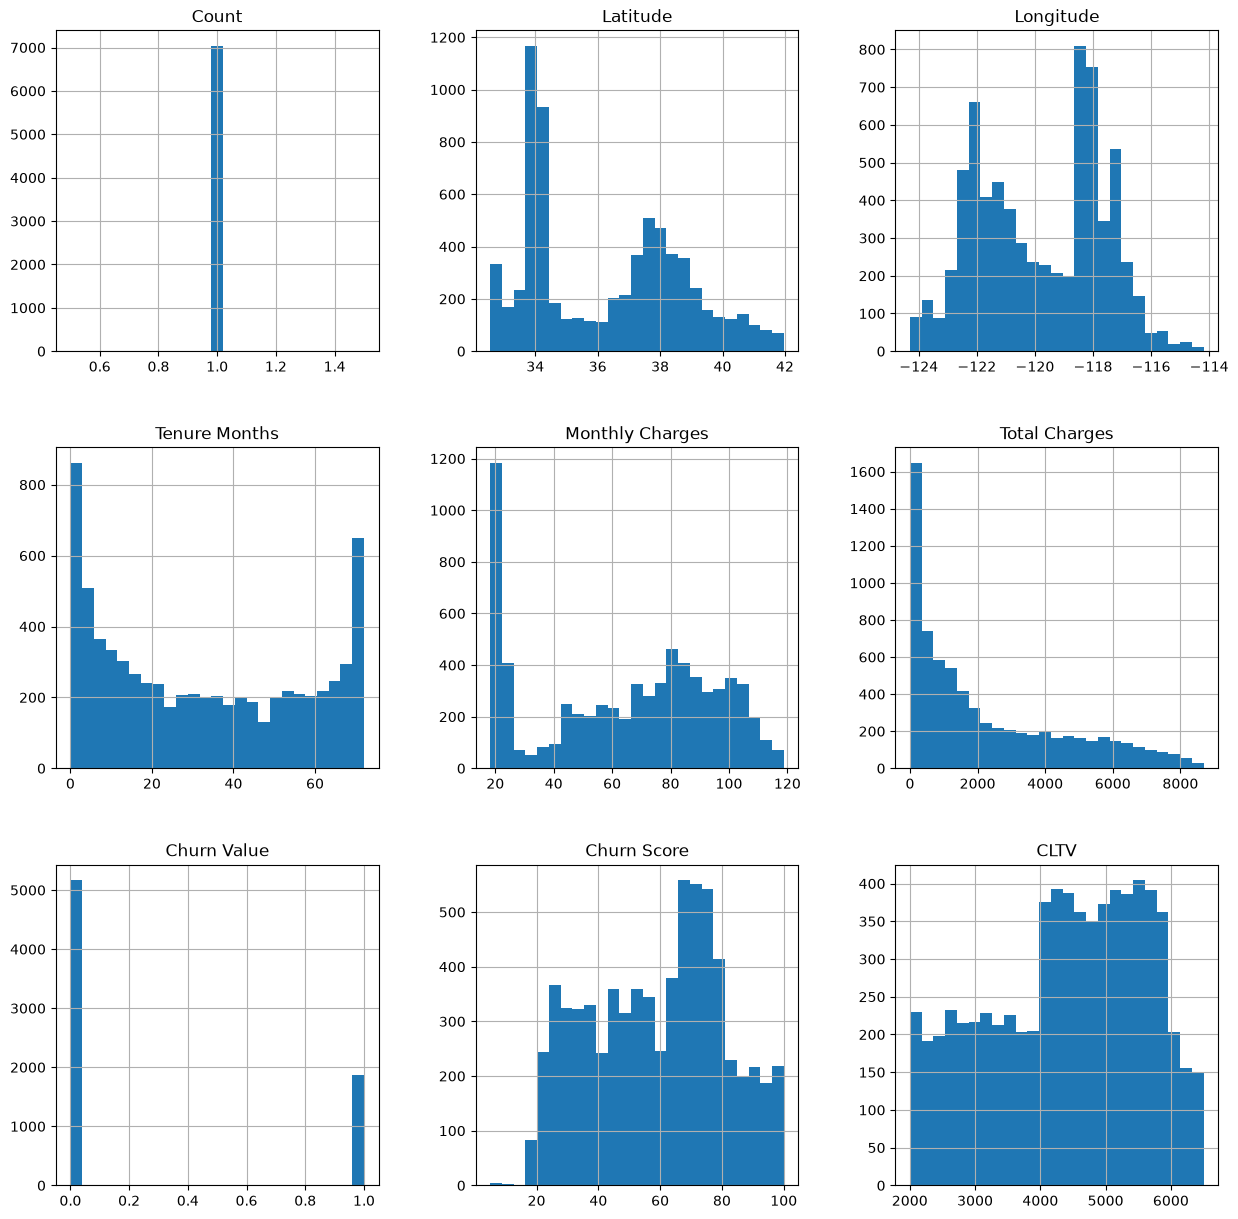

In [26]:
num_attributes.hist(bins = 25, figsize = (15, 15))

#### 8.1.3 Variáveis Categóricas

In [27]:
#limpando as colunas categóricas que nao vou usar
cat_attributes_2 = cat_attributes.drop(['CustomerID', 'Country', 'State', 'Lat Long', 'Churn Label', 'Churn Reason'], axis = 1)

In [28]:
aux = cat_attributes.loc[:, ['City', 'Churn Label', 'CustomerID']].groupby(['City', 'Churn Label']).count().sort_values(by = 'CustomerID', ascending = False).reset_index()
aux

#aux.head(10).plot(kind = 'bar', x = 'City', y = 'Churn Label')
#plt.show()

,City,Churn Label,CustomerID
0,Los Angeles,No,215
1,San Diego,No,100
2,Los Angeles,Yes,90
3,San Jose,No,83
4,Sacramento,No,82
...,...,...,...
1945,Alpaugh,No,1
1946,Mentone,Yes,1
1947,Mendota,Yes,1
1948,Yorkville,Yes,1


In [29]:
cat_attributes_2.dtypes

City                 str
Gender               str
Senior Citizen       str
Partner              str
Dependents           str
Phone Service        str
Multiple Lines       str
Internet Service     str
Online Security      str
Online Backup        str
Device Protection    str
Tech Support         str
Streaming TV         str
Streaming Movies     str
Contract             str
Paperless Billing    str
Payment Method       str
dtype: object

In [30]:
num_attributes.dtypes

Count                int64
Latitude           float64
Longitude          float64
Tenure Months        int64
Monthly Charges    float64
Total Charges      float64
Churn Value          int64
Churn Score          int64
CLTV                 int64
dtype: object

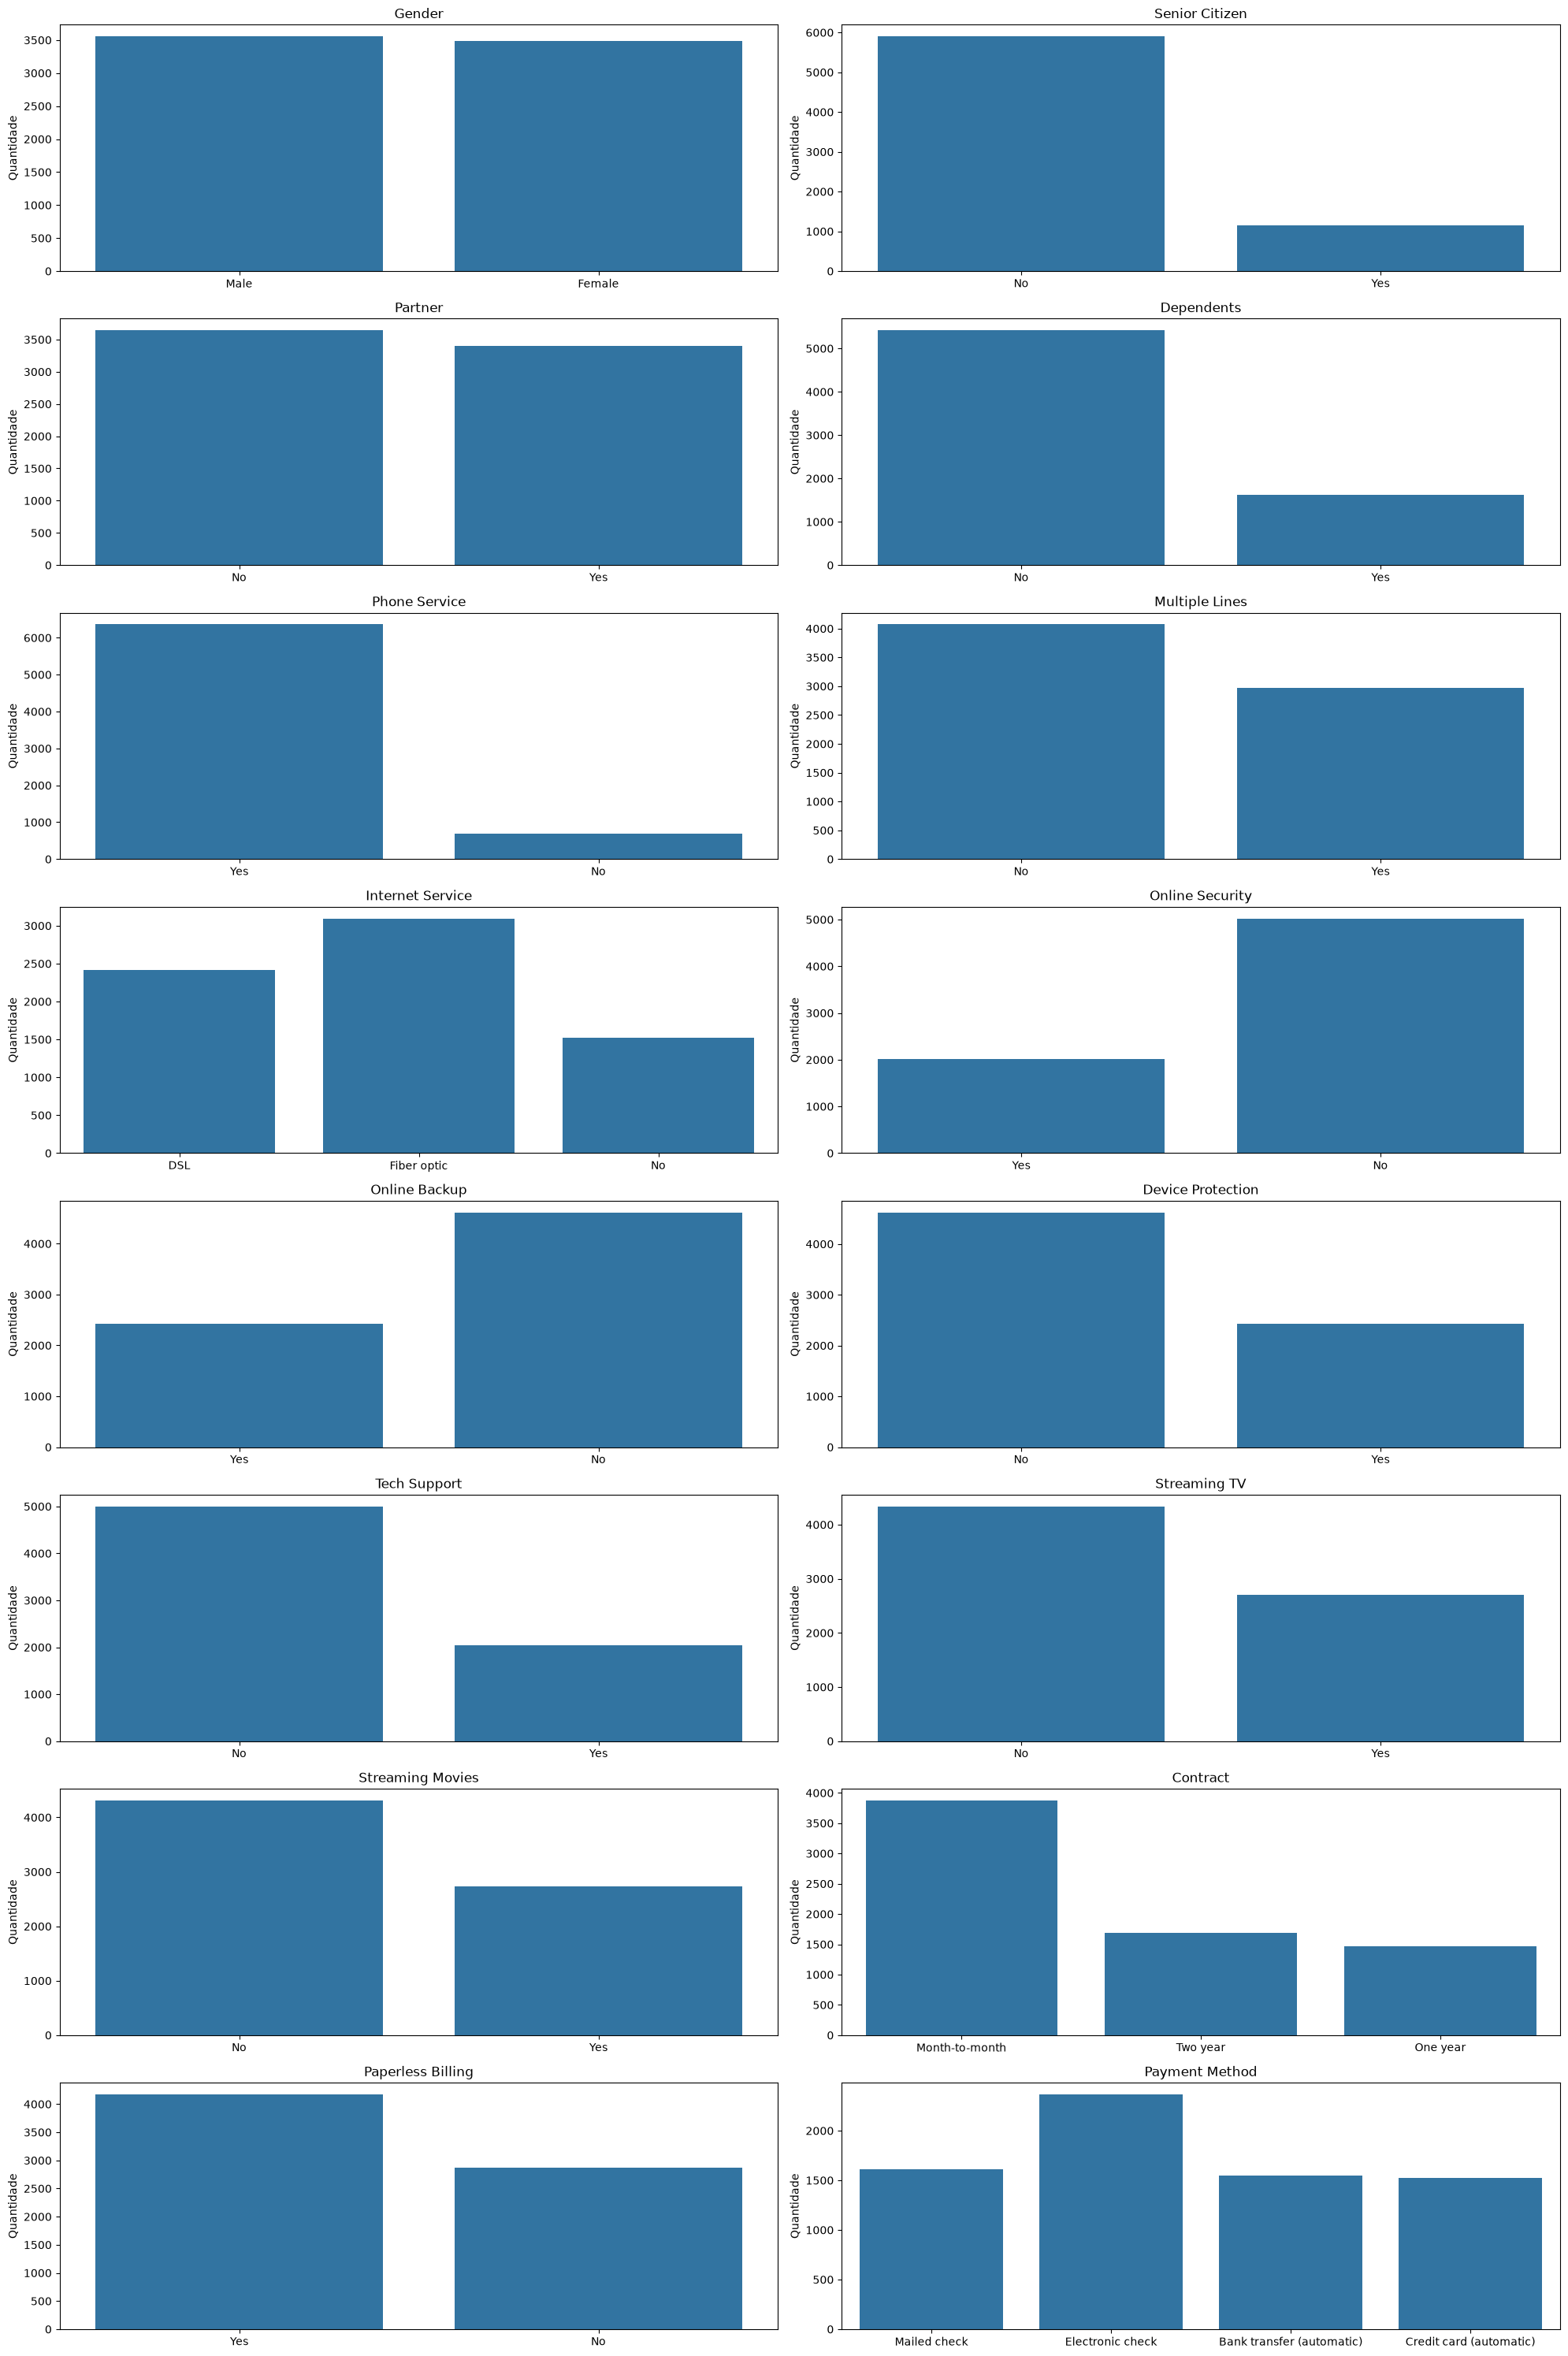

In [31]:
features = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 
           'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 
           'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

fig, axes = plt.subplots(8, 2, figsize = (20, 30))

for ax, feature in zip(axes.flat, features):
    sns.countplot(data = cat_attributes_2, x = feature, ax = ax)
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

               CustomerID
City                     
Los Angeles           305
San Diego             150
San Jose              112
Sacramento            108
San Francisco         104
...                   ...
Lafayette               4
Ladera Ranch            4
La Honda                4
La Grange               4
Keyes                   4

[1129 rows x 1 columns]


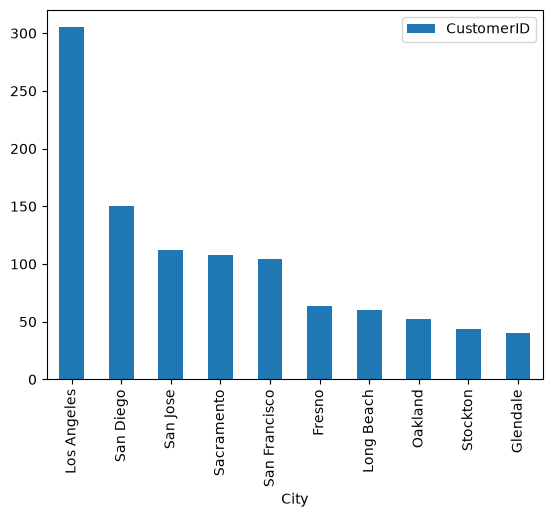

In [32]:
aux_1 = cat_attributes.loc[:, ['City', 'CustomerID']].groupby('City').count().sort_values(by = 'CustomerID', ascending = False)

aux_1.head(10).plot(kind = 'bar')
print(aux_1)

#### 8.1.4 Análise Bivariada

In [33]:
#clientes que tem parceiros e dependentes tem menor probabilidade de CHURN

aux = df3.loc[(df3['Partner'] == "Yes"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

aux_1 = df3.loc[(df3['Partner'] == "No"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_1

  Churn Label  proportion
0          No    0.803351
1         Yes    0.196649


,Churn Label,proportion
0,No,0.67042
1,Yes,0.32958


In [34]:
aux2 = df3.loc[(df3['Dependents'] == "Yes"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux2)

aux_4 = df3.loc[(df3['Dependents'] == "No"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_4

  Churn Label  proportion
0          No    0.934849
1         Yes    0.065151


,Churn Label,proportion
0,No,0.674483
1,Yes,0.325517


Text(0.5, 0, 'Churn')

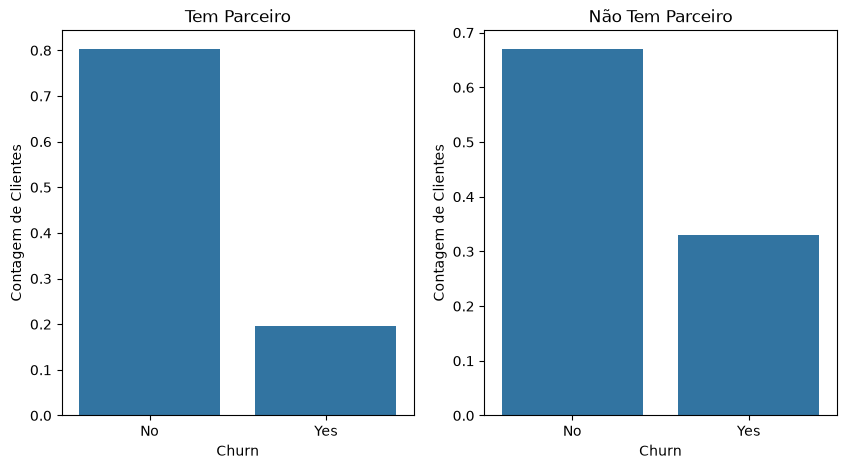

In [35]:
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Tem Parceiro')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 2, 2)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Não Tem Parceiro')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

Text(0.5, 0, 'Churn')

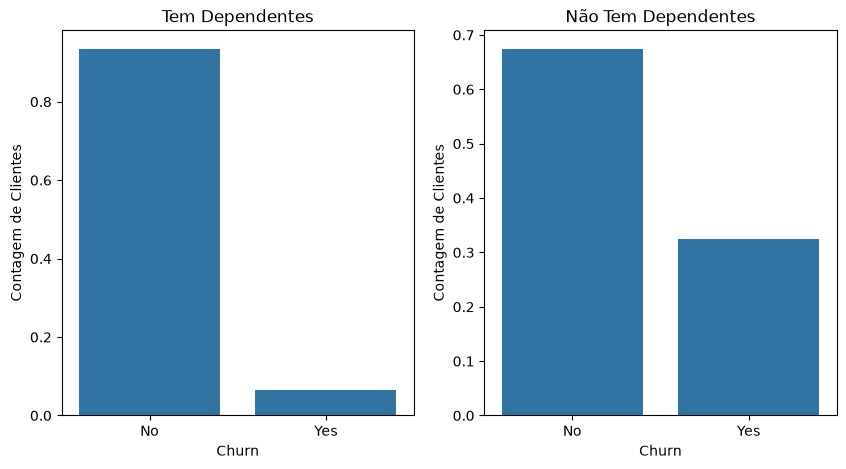

In [36]:
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data = aux2, x = 'Churn Label', y = 'proportion')
plt.title('Tem Dependentes')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 2, 2)
sns.barplot(data = aux_4, x = 'Churn Label', y = 'proportion')
plt.title('Não Tem Dependentes')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

  Churn Label  proportion
0          No    0.583187
1         Yes    0.416813
  Churn Label  proportion
0          No    0.763938
1         Yes    0.236062


Text(0.5, 0, 'Churn')

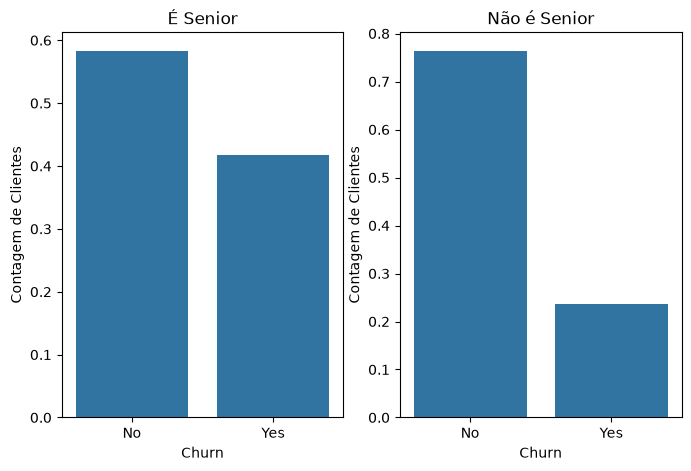

In [37]:
aux = df3.loc[(df3['Senior Citizen'] == "Yes"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

plt.figure(figsize = (8, 5))
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('É Senior')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')



aux = df3.loc[(df3['Senior Citizen'] == "No"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

plt.subplot(1, 2, 2)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Não é Senior')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

# aux = df3.loc[:, ['Churn Label', 'Senior Citizen']].groupby('Churn Label').value_counts().reset_index()
# sns.barplot(data = aux, x = 'Churn Label', y = 'count', hue ='Senior Citizen')
# plt.ylabel('Contagem de Clientes')
# plt.xlabel('Churn')

# print(aux)

In [38]:
df3.columns

Index(['Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude',
       'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

  Churn Label  proportion
0          No    0.853888
1         Yes    0.146112


Text(0.5, 0, 'Churn')

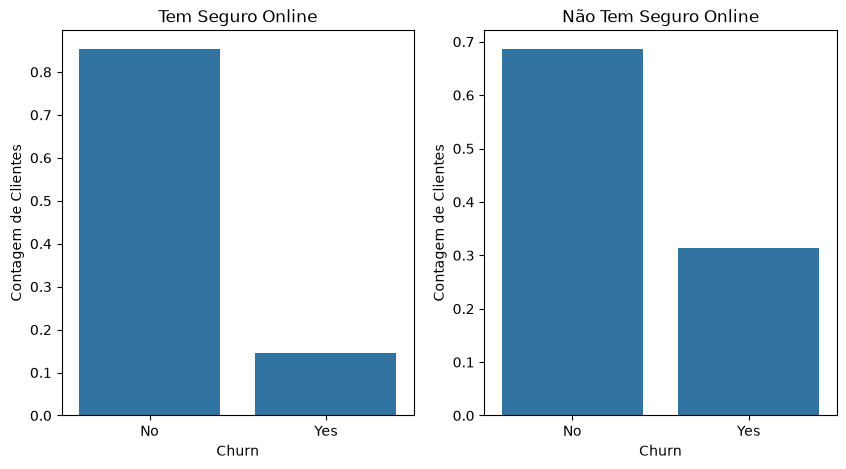

In [39]:
aux = df3.loc[(df3['Online Security'] == "Yes"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

aux_1 = df3.loc[(df3['Online Security'] == "No"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_1

plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Tem Seguro Online')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 2, 2)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Não Tem Seguro Online')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

  Churn Label  proportion
0          No    0.784685
1         Yes    0.215315


Text(0.5, 0, 'Churn')

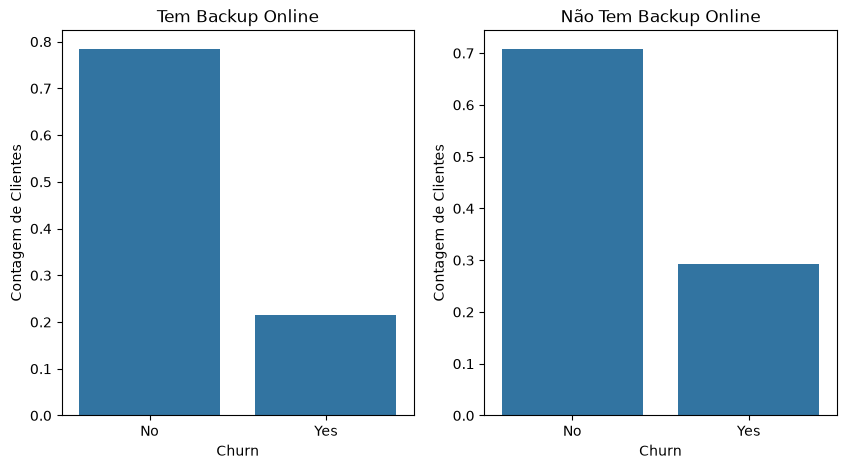

In [40]:
aux = df3.loc[(df3['Online Backup'] == "Yes"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

aux_1 = df3.loc[(df3['Online Backup'] == "No"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_1

plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Tem Backup Online')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 2, 2)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Não Tem Backup Online')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

  Churn Label  proportion
0          No    0.774979
1         Yes    0.225021


Text(0.5, 0, 'Churn')

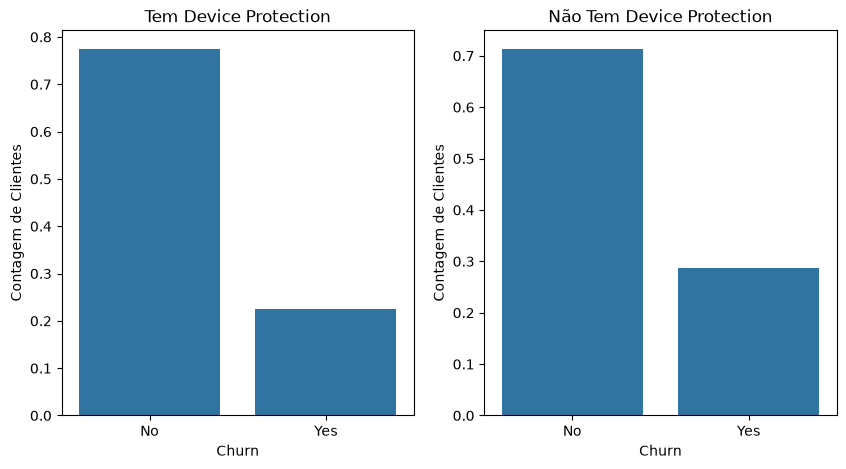

In [41]:
aux = df3.loc[(df3['Device Protection'] == "Yes"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

aux_1 = df3.loc[(df3['Device Protection'] == "No"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_1

plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Tem Device Protection')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 2, 2)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Não Tem Device Protection')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

  Churn Label  proportion
0          No    0.848337
1         Yes    0.151663


Text(0.5, 0, 'Churn')

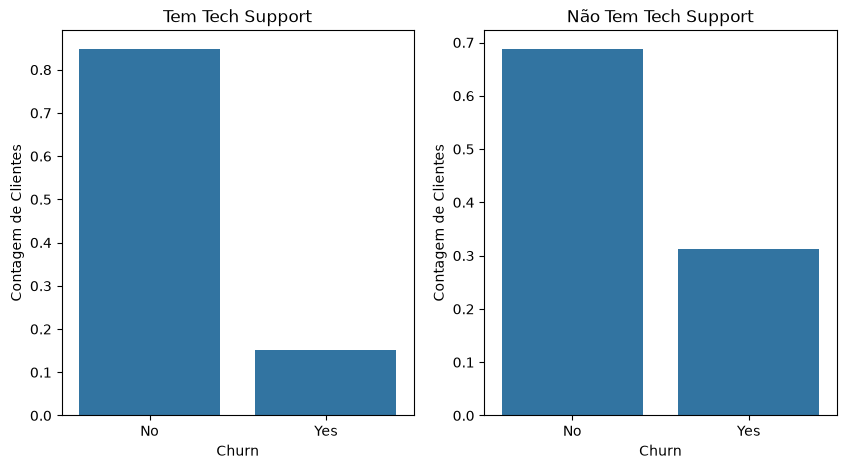

In [42]:
aux = df3.loc[(df3['Tech Support'] == "Yes"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

aux_1 = df3.loc[(df3['Tech Support'] == "No"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_1

plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Tem Tech Support')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 2, 2)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Não Tem Tech Support')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

  Churn Label  proportion
0          No    0.699298
1         Yes    0.300702


Text(0.5, 0, 'Churn')

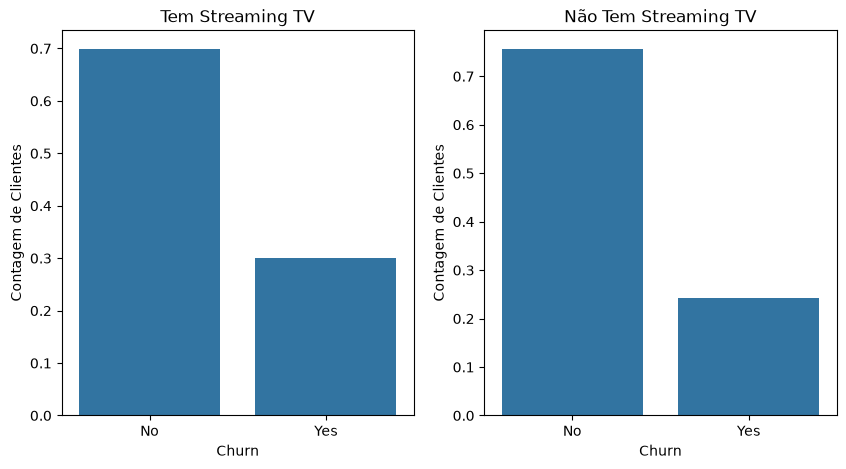

In [43]:
aux = df3.loc[(df3['Streaming TV'] == "Yes"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

aux_1 = df3.loc[(df3['Streaming TV'] == "No"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_1

plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Tem Streaming TV')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 2, 2)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Não Tem Streaming TV')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

Text(0.5, 0, 'Churn')

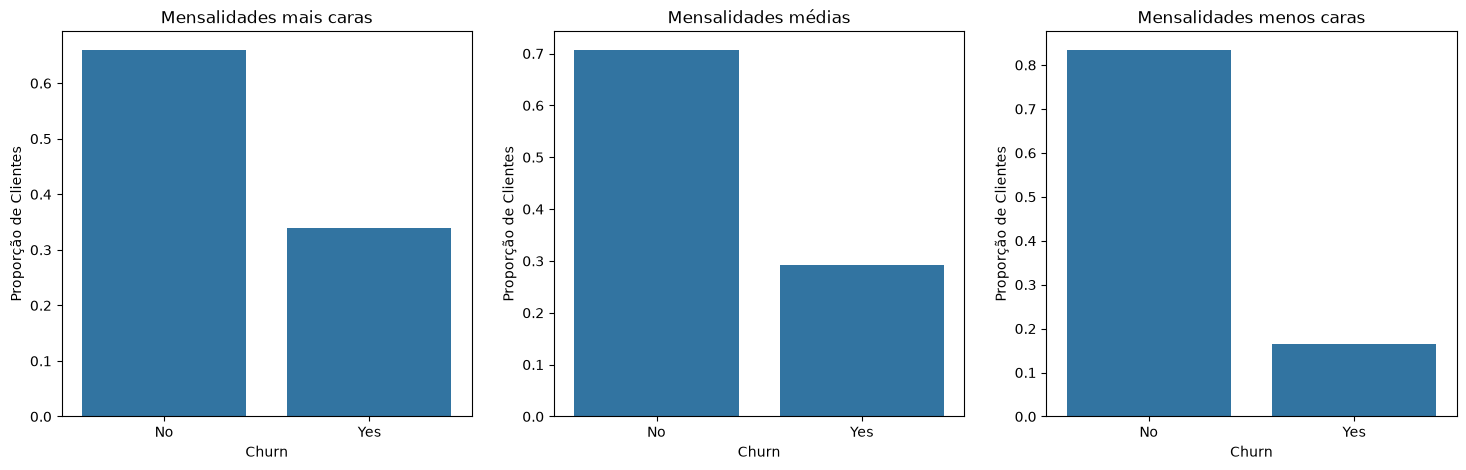

In [44]:
#Quem tem maior mensalidade tem menir probabilidade de churn?

aux = df3.loc[(df3['Monthly Charges'] >= 80), 'Churn Label'].value_counts(normalize = True).reset_index()
aux

aux_0 = df3.loc[(df3['Monthly Charges'] < 80) & (df3['Monthly Charges'] >= 54), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_0

aux_1 = df3.loc[(df3['Monthly Charges'] < 54), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_1

plt.figure(figsize = (18, 5))
plt.subplot(1, 3, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Mensalidades mais caras')
plt.ylabel('Proporção de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 3, 2)
sns.barplot(data = aux_0, x = 'Churn Label', y = 'proportion')
plt.title('Mensalidades médias')
plt.ylabel('Proporção de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 3, 3)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Mensalidades menos caras')
plt.ylabel('Proporção de Clientes')
plt.xlabel('Churn')

# df3['Monthly Charges'].sort_values(ascending = False).head(4500)


In [45]:
#quantos clientes tem mensalidade cara, média e barata

aux = df3.loc[(df3['Monthly Charges'] >= 80), 'Churn Label'].count()


aux_0 = df3.loc[(df3['Monthly Charges'] < 80) & (df3['Monthly Charges'] >= 54), 'Churn Label'].count()


aux_1 = df3.loc[(df3['Monthly Charges'] < 54), 'Churn Label'].count()

print(f"cara: {aux}, média: {aux_0}, barata: {aux_1}")

cara: 2677, média: 1858, barata: 2508


In [46]:
#Quem mora numa cidade com maior número de clientes, tem probabilidade de maior churn?

cat_attributes.loc[:, ['City', 'CustomerID']].groupby('City').count().sort_values(by = 'CustomerID', ascending = False).head(20).reset_index()

,City,CustomerID
0,Los Angeles,305
1,San Diego,150
2,San Jose,112
3,Sacramento,108
4,San Francisco,104
5,Fresno,64
6,Long Beach,60
7,Oakland,52
8,Stockton,44
9,Glendale,40


Text(0.5, 0, 'Churn')

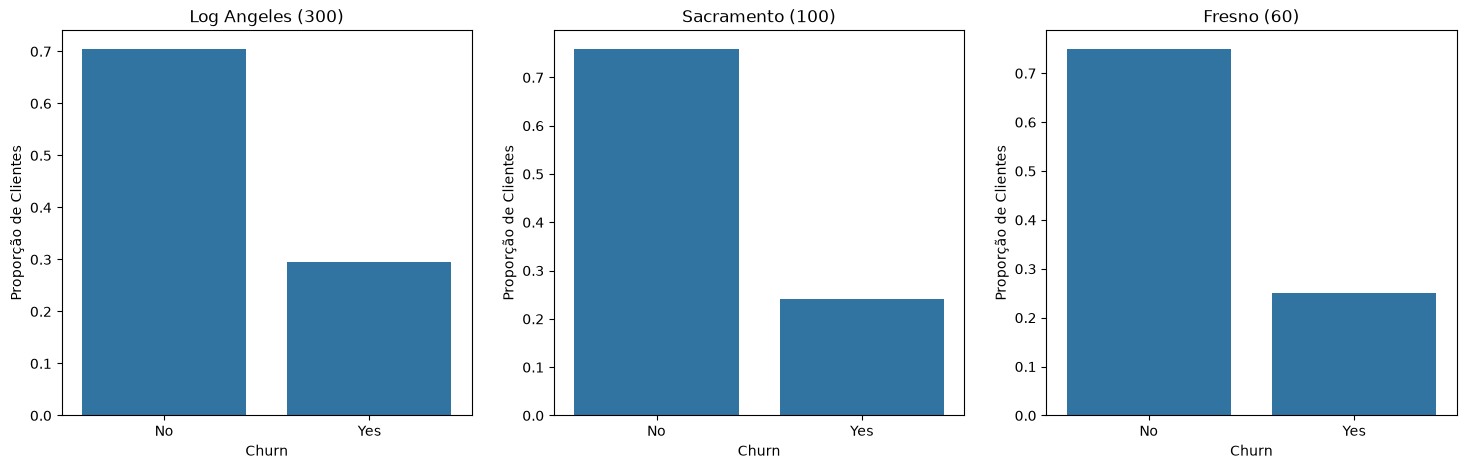

In [47]:
aux = df3.loc[(df3['City'] == 'Los Angeles'), ['Churn Label']].value_counts(normalize = True).reset_index()

aux_1 = df3.loc[(df3['City'] == 'Sacramento'), ['Churn Label']].value_counts(normalize = True).reset_index()

aux_2 = df3.loc[(df3['City'] == 'Fresno'), ['Churn Label']].value_counts(normalize = True).reset_index()

plt.figure(figsize = (18, 5))
plt.subplot(1, 3, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Log Angeles (300)')
plt.ylabel('Proporção de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 3, 2)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Sacramento (100)')
plt.ylabel('Proporção de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 3, 3)
sns.barplot(data = aux_2, x = 'Churn Label', y = 'proportion')
plt.title('Fresno (60)')
plt.ylabel('Proporção de Clientes')
plt.xlabel('Churn')

  Churn Label  proportion
0          No    0.738397
1         Yes    0.261603


Text(0.5, 0, 'Churn')

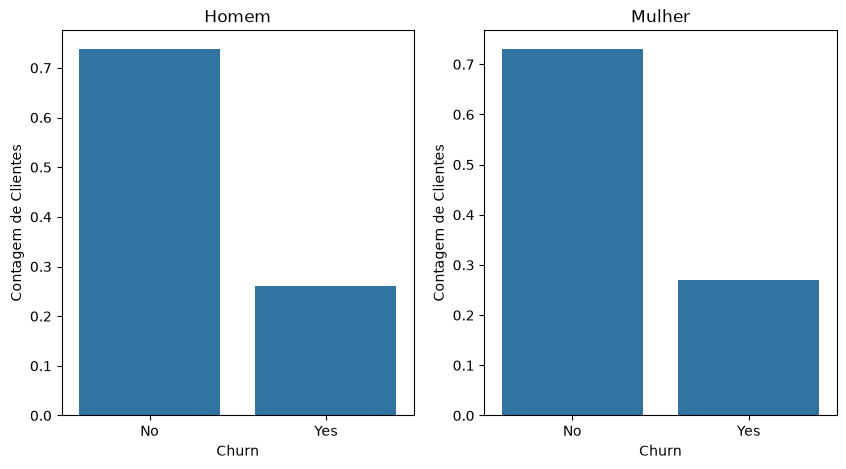

In [48]:
aux = df3.loc[(df3['Gender'] == "Male"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

aux_1 = df3.loc[(df3['Gender'] == "Female"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_1

plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Homem')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(1, 2, 2)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Mulher')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

  Churn Label  proportion
0          No    0.832902
1         Yes    0.167098


Text(0.5, 0, 'Churn')

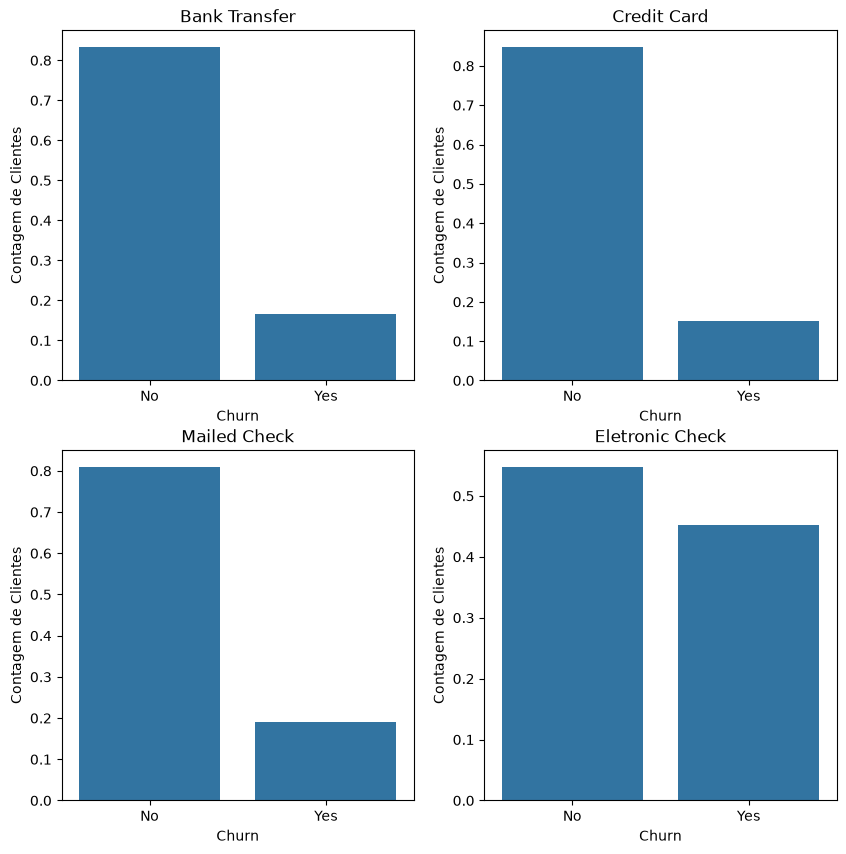

In [49]:
aux = df3.loc[(df3['Payment Method'] == "Bank transfer (automatic)"), 'Churn Label'].value_counts(normalize = True).reset_index()
print(aux)

aux_1 = df3.loc[(df3['Payment Method'] == "Credit card (automatic)"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_1

aux_2 = df3.loc[(df3['Payment Method'] == "Mailed check"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_2

aux_3 = df3.loc[(df3['Payment Method'] == "Electronic check"), 'Churn Label'].value_counts(normalize = True).reset_index()
aux_3

plt.figure(figsize = (10, 10))
plt.subplot(2, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Bank Transfer')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(2, 2, 2)
sns.barplot(data = aux_1, x = 'Churn Label', y = 'proportion')
plt.title('Credit Card')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(2, 2, 3)
sns.barplot(data = aux_2, x = 'Churn Label', y = 'proportion')
plt.title('Mailed Check')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

plt.subplot(2, 2, 4)
sns.barplot(data = aux_3, x = 'Churn Label', y = 'proportion')
plt.title('Eletronic Check')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

#df3['Payment Method'].head(20)

In [50]:
aux = df3.loc[(df3['Payment Method'] == "Bank transfer (automatic)"), 'Churn Label'].count()


aux_1 = df3.loc[(df3['Payment Method'] == "Credit card (automatic)"), 'Churn Label'].count()


aux_2 = df3.loc[(df3['Payment Method'] == "Mailed check"), 'Churn Label'].count()


aux_3 = df3.loc[(df3['Payment Method'] == "Electronic check"), 'Churn Label'].count()


aux_4 = df3.loc[:, ['Payment Method', 'Monthly Charges']].groupby('Payment Method').count().reset_index()
aux_4

,Payment Method,Monthly Charges
0,Bank transfer (automatic),1544
1,Credit card (automatic),1522
2,Electronic check,2365
3,Mailed check,1612


##### 1) Quem recebe cobrança via digital tem maior chance de churn
##### 2) Quem recebe cobrança com papel tem menor CHURN
Ao observar os graficos, nota-se que clientes que recebem a conta de forma digital tem maior proporcao de churn se comparado aos clientes que nao recebem. Entao a hipotece 2 e verdadeira e a hipotese 1 nao.

Text(0.5, 0, 'Churn')

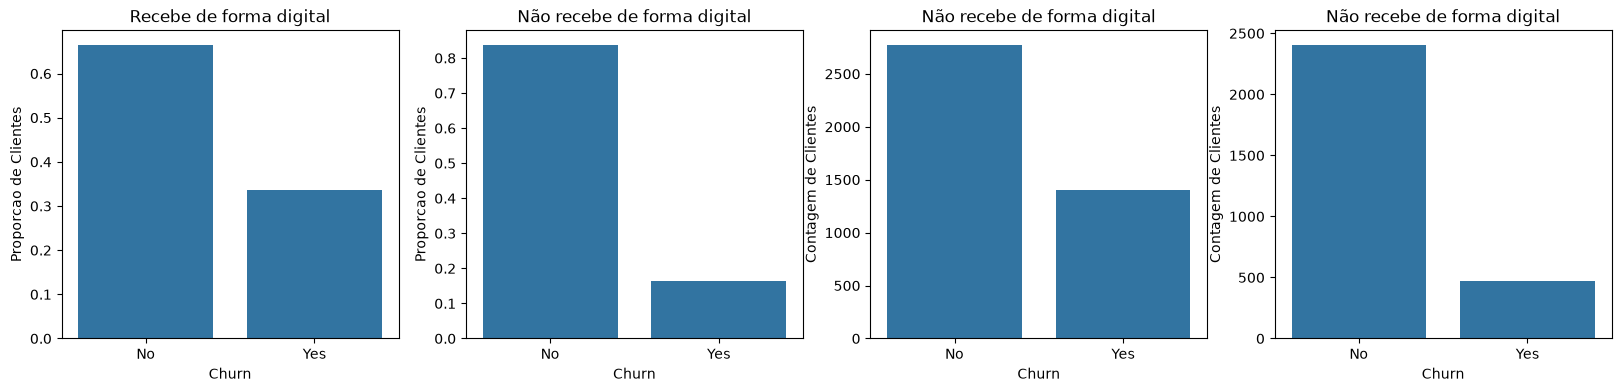

In [51]:
# data com a proporcao de clientes que recebem a conta de forma digital
aux = df3.loc[(df3['Paperless Billing'] == "Yes"), 'Churn Label'].value_counts(normalize = True).reset_index()
# data com a proporcao clientes que nao recebem a conta de forma digital
aux1 = df3.loc[(df3['Paperless Billing'] == "No"), 'Churn Label'].value_counts(normalize = True).reset_index()
# data com o total de clientes que recebem a conta de forma digital
aux2 = df3.loc[(df3['Paperless Billing'] == "Yes"), 'Churn Label'].value_counts().reset_index()
# data com o total de clientes que nao recebem a conta de forma digital
aux3 = df3.loc[(df3['Paperless Billing'] == "No"), 'Churn Label'].value_counts().reset_index()

# grafico de barras relacionando churn a categoria de clientes que recebem a conta de forma digital
plt.figure(figsize = (20, 4))
plt.subplot(1, 4, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Recebe de forma digital')
plt.ylabel('Proporcao de Clientes')
plt.xlabel('Churn')

# grafico de barras relacionando churn a categoria de clientes que recebem a conta de forma digital
plt.subplot(1, 4, 2)
sns.barplot(data = aux1, x = 'Churn Label', y = 'proportion')
plt.title('Não recebe de forma digital')
plt.ylabel('Proporcao de Clientes')
plt.xlabel('Churn')

# grafico de barras relacionando churn a categoria de clientes que recebem a conta de forma digital
plt.subplot(1, 4, 3)
sns.barplot(data = aux2, x = 'Churn Label', y = 'count')
plt.title('Não recebe de forma digital')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

# grafico de barras relacionando churn a categoria de clientes que recebem a conta de forma digital
plt.subplot(1, 4, 4)
sns.barplot(data = aux3, x = 'Churn Label', y = 'count')
plt.title('Não recebe de forma digital')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

##### 3) Serviço de internet que não contratou Fiber Optic tende a ter maior CHURN
Hipotese falsa, tendo em vista que a proporcao de clientes que dao churn com servico de internet fiber optic é em torno de 40%, enquanto aqueles do servico DSL que dao churn correspondem a
aproximadamente 20%.

Text(0.5, 0, 'Churn')

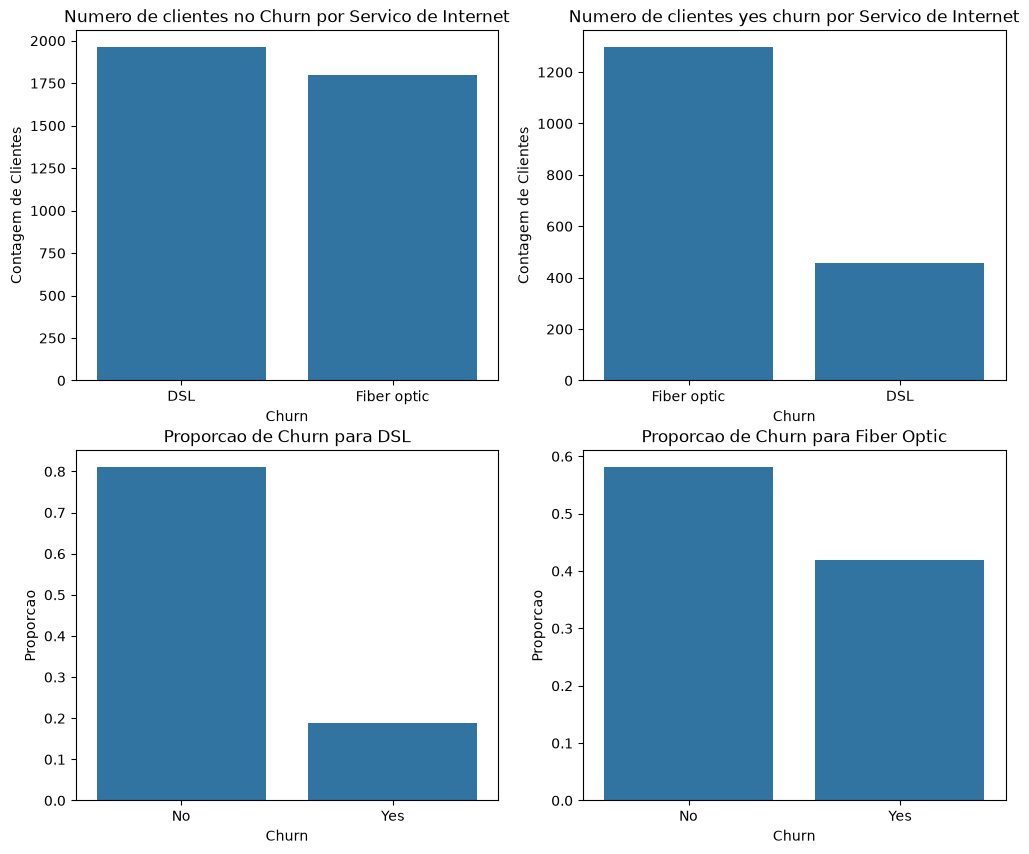

In [52]:
# data com a contagem de clientes por tipo de internet
aux = df3.loc[:, ['Internet Service','Churn Label']].value_counts().reset_index()
aux1 = aux.loc[(aux['Internet Service'] != 'No') & (aux['Churn Label'] == 'No'), :]
aux2 = aux.loc[(aux['Internet Service'] != 'No') & (aux['Churn Label'] == 'Yes'), :]

# data com a proporcao de clientes que deram ou nao churn por tipo servico de internet
aux3 = df3[df3['Internet Service'] == 'DSL']['Churn Label'].value_counts(normalize=True).reset_index()
aux4 = df3[df3['Internet Service'] == 'Fiber optic']['Churn Label'].value_counts(normalize=True).reset_index()
plt.figure( figsize=(12,10) )

# grafico para comparar a numero de clientes sem churn por servico de internet
plt.subplot(2, 2, 1)
sns.barplot(data = aux1, x = 'Internet Service', y = 'count')
plt.title('Numero de clientes no Churn por Servico de Internet')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

# grafico para comparar a numero de clientes que deram churn por servico de internet
plt.subplot(2, 2, 2)
sns.barplot(data = aux2, x = 'Internet Service', y = 'count')
plt.title('Numero de clientes yes churn por Servico de Internet')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

# grafico com a proporcao para comparar a numero de clientes que nao deram churn para servico de internet DSL
plt.subplot(2, 2, 3)
sns.barplot(data = aux3, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de Churn para DSL')
plt.ylabel('Proporcao')
plt.xlabel('Churn')

# grafico com a proporcao para comparar a numero de clientes que deram churn para servico de internet fiber optic
plt.subplot(2, 2, 4)
sns.barplot(data = aux4, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de Churn para Fiber Optic')
plt.ylabel('Proporcao')
plt.xlabel('Churn')

##### 4) Clientes sem serviço de internet tende a ter maior CHURN
A hipotese e falsa, tendo em vista que a proporcao de clientes que deram churn com servico de intenert e superior a proporcao de churn para clientes que nao possuem servico de internet

Text(0.5, 0, 'Churn')

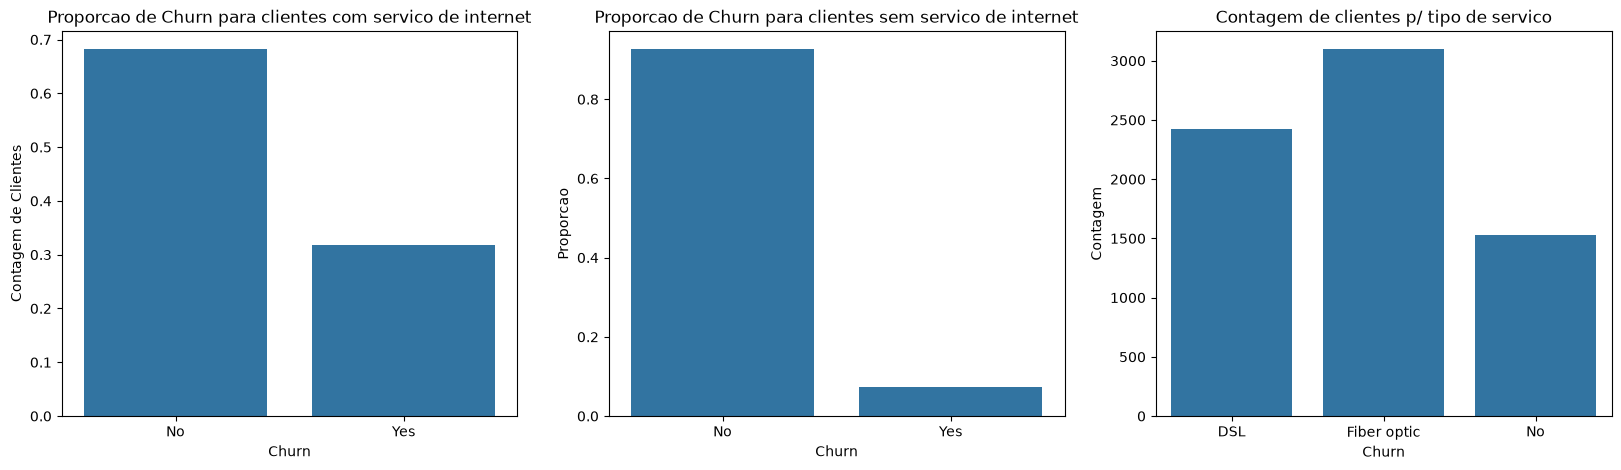

In [53]:
# data com a contagem de clientes que deram ou nao churn e nao possuem servico de internet
aux = df3[df3['Internet Service'] != 'No']['Churn Label'].value_counts(normalize=True).reset_index()

# data com a proporcao de clientes que deram ou nao churn e nao possuem servico de internet
aux1 = df3[df3['Internet Service'] == 'No']['Churn Label'].value_counts(normalize=True).reset_index()

aux2 = df3.loc[:, ['Internet Service', 'Monthly Charges']].groupby('Internet Service').count().reset_index()

plt.figure( figsize=(20, 5) )
# grafico da proporcao de churn para clientes com servico de internet 
plt.subplot(1, 3, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de Churn para clientes com servico de internet')
plt.ylabel('Contagem de Clientes')
plt.xlabel('Churn')

# grafico da proporcao de churn para clientes sem servico de internet
plt.subplot(1, 3, 2)
sns.barplot(data = aux1, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de Churn para clientes sem servico de internet')
plt.ylabel('Proporcao')
plt.xlabel('Churn')

# grafico da proporcao de churn para clientes sem servico de internet
plt.subplot(1, 3, 3)
sns.barplot(data = aux2, x = 'Internet Service', y = 'Monthly Charges')
plt.title('Contagem de clientes p/ tipo de servico')
plt.ylabel('Contagem')
plt.xlabel('Churn')

##### 5) Clientes com Phone Service tem menor CHURN
Hipotese falsa. Para clientes com ou sem phone service as proporcoes de churn sao bem proximas.

Text(0.5, 0, 'Churn')

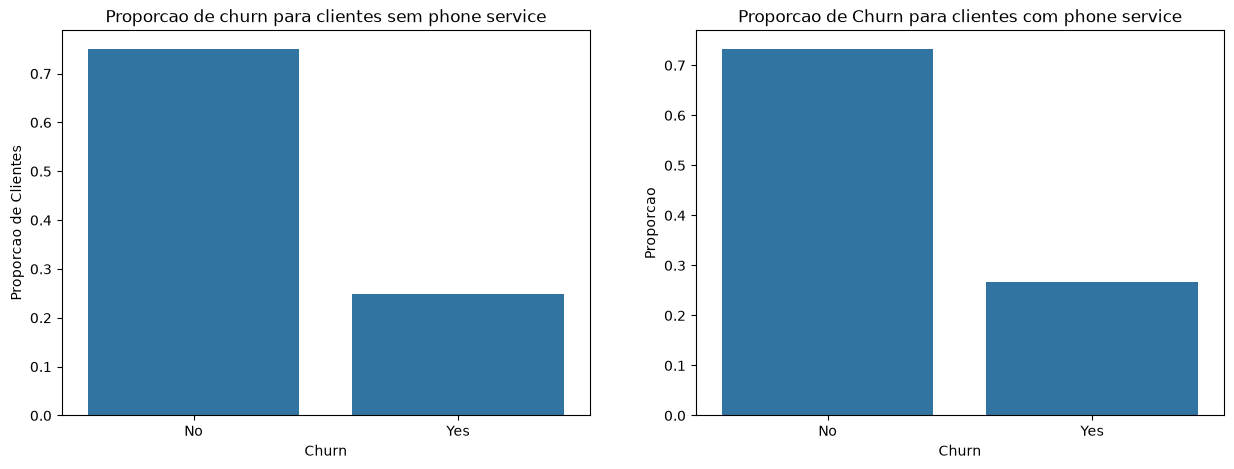

In [54]:
# data com a proporcao de clientes que deram ou nao churn e nao possuem phone service
aux = df3[df3['Phone Service'] == 'No']['Churn Label'].value_counts(normalize=True).reset_index()

# data com a proporcao de clientes que deram ou nao churn e possuem phone service
aux1 = df3[df3['Phone Service'] == 'Yes']['Churn Label'].value_counts(normalize=True).reset_index()

plt.figure( figsize=(15,5) )
# grafico da proporcao de churn para clientes sem phone de internet 
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de churn para clientes sem phone service')
plt.ylabel('Proporcao de Clientes')
plt.xlabel('Churn')
# grafico da proporcao de churn para clientes com phone service
plt.subplot(1, 2, 2)
sns.barplot(data = aux1, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de Churn para clientes com phone service')
plt.ylabel('Proporcao')
plt.xlabel('Churn')

##### 6)  Clientes com Multiple Lines tem menor CHURN
Hipotese falsa. A proporcao de churn para clientes com Multiple Lines e maior do que a proporcao de churn para clientes que nao possuem este servico.

Text(0.5, 0, 'Churn')

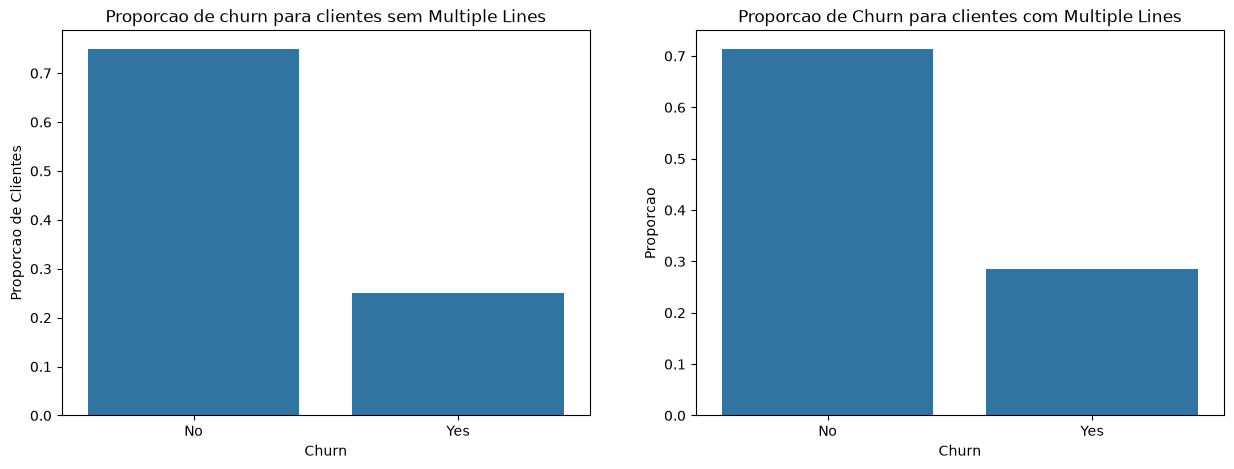

In [55]:
# data com a proporcao de clientes que deram ou nao churn e nao possuem Multiple Lines
aux = df3[df3['Multiple Lines'] == 'No']['Churn Label'].value_counts(normalize=True).reset_index()

# data com a proporcao de clientes que deram ou nao churn e possuem Multiple Lines
aux1 = df3[df3['Multiple Lines'] == 'Yes']['Churn Label'].value_counts(normalize=True).reset_index()

plt.figure( figsize=(15,5) )
# grafico da proporcao de churn para clientes sem phone de internet 
plt.subplot(1, 2, 1)
sns.barplot(data = aux, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de churn para clientes sem Multiple Lines')
plt.ylabel('Proporcao de Clientes')
plt.xlabel('Churn')

# grafico da proporcao de churn para clientes com Multiple Lines
plt.subplot(1, 2, 2)
sns.barplot(data = aux1, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de Churn para clientes com Multiple Lines')
plt.ylabel('Proporcao')
plt.xlabel('Churn')

##### 6)  Clientes com menor tempo de contrato tende a ter menor CHURN
##### 7) Clientes com mais tempo de contrato tende a ter menor CHURN
Hipoteses Verdadeiras, clientes com menor tempo de contrato tem maior proporcao de churn se comparado aos clientes com contrato mais longo.

Text(0.5, 0, 'Churn')

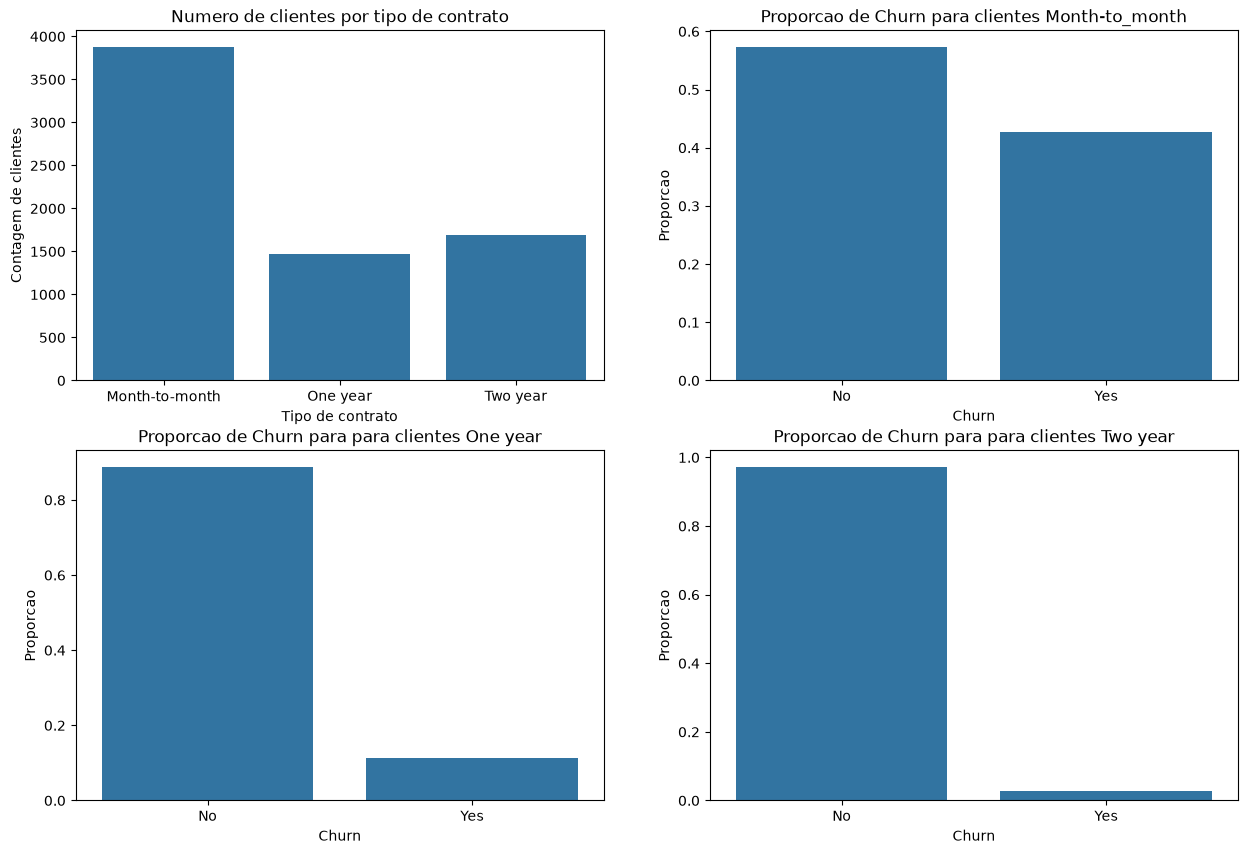

In [56]:
# data com contagem de clientes por tipo de contrato
aux = df3.loc[:, ['Contract', 'City']].groupby('Contract').count().reset_index()
# data com a proporcao de clientes que deram ou nao churn e possuem contrato month to month
aux1 = df3[df3['Contract'] == 'Month-to-month']['Churn Label'].value_counts(normalize=True).reset_index()
# data com a proporcao de clientes que deram ou nao churn e possuem contrato one year
aux2 = df3[df3['Contract'] == 'One year']['Churn Label'].value_counts(normalize=True).reset_index()
# data com a proporcao de clientes que deram ou nao churn e possuem contrato two year
aux3 = df3[df3['Contract'] == 'Two year']['Churn Label'].value_counts(normalize=True).reset_index()

plt.figure( figsize=(15,10) )
# grafico da contagem de clientes para cada tipo de contrato
plt.subplot(2, 2, 1)
sns.barplot(data = aux, x = 'Contract', y = 'City')
plt.title('Numero de clientes por tipo de contrato')
plt.ylabel('Contagem de clientes')
plt.xlabel('Tipo de contrato')
# grafico da proporcao de churn para clientes com Contract Month to Month
plt.subplot(2, 2, 2)
sns.barplot(data = aux1, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de Churn para clientes Month-to_month')
plt.ylabel('Proporcao')
plt.xlabel('Churn')
# grafico da proporcao de churn para clientes com Contract One year
plt.subplot(2, 2, 3)
sns.barplot(data = aux2, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de Churn para para clientes One year')
plt.ylabel('Proporcao')
plt.xlabel('Churn')
# grafico da proporcao de churn para clientes com Contract Two year
plt.subplot(2, 2, 4)
sns.barplot(data = aux3, x = 'Churn Label', y = 'proportion')
plt.title('Proporcao de Churn para para clientes Two year')
plt.ylabel('Proporcao')
plt.xlabel('Churn')

1) Clientes com partner tem menos chance de ter CHURN: Verdadeiro
2) Clientes com dependents tem menos chance de ter CHURN: Verdadeira
3) Clientes Senior Citizens tem menos chance de ter CHURN: Falsa
4) Clientes com seguro online tem menor CHURN: Verdadeiro
5) Clientes com backup online tem menor CHURN: Verdadeiro
5) Clientes com device protection tem menor CHURN: Verdadeiro
6) Clientes com tech support tem menor CHURN: Verdadeiro
7) Clientes com streaming tv tem menor CHURN: Falso
8) Clientes com menor valor mensal tendem a ter menos Churn: Falso
9) Cidades com mais clientes tem menor CHURN: Falso
10) Homens tendem a gerar mais CHURN que mulheres: Falso
11) Clientes que nao pagam via cartao de credito tem maior possibilidade de CHURN: Parcialmente Verdadeiro
12) Quem recebe cobrança via digital tem maior chance de CHURN: Verdadeiro
13) Serviço de internet que não contratou Fiber Optic tende a ter maior CHURN: Falso
14) Clientes sem serviço de internet tende a ter maior CHURN: Falso
15) Clientes com Phone Service tem menor CHURN: Falso
16) Clientes com Multiple Lines tem menor CHURN: Falso
17) Clientes com mais tempo de contrato tende a ter menor CHURN: Verdadeiro

In [57]:
resultados = pd.DataFrame({ 'Hipoteses' : ['1','2','3','4', '5','6','7','8', '9','10','11','12', '13','14','15','16', '17', '18'],
                            'Avaliacao' : ['V','V','F','V', 'V','V','V','F', 'F','F','F','PV', 'V','F','F','F', 'F', 'V']})
resultados

,Hipoteses,Avaliacao
0,1,V
1,2,V
2,3,F
3,4,V
4,5,V
5,6,V
6,7,V
7,8,F
8,9,F
9,10,F


### 8.2 Análise Multivariada

8.2.1 Variáveis Numéricas

<Axes: >

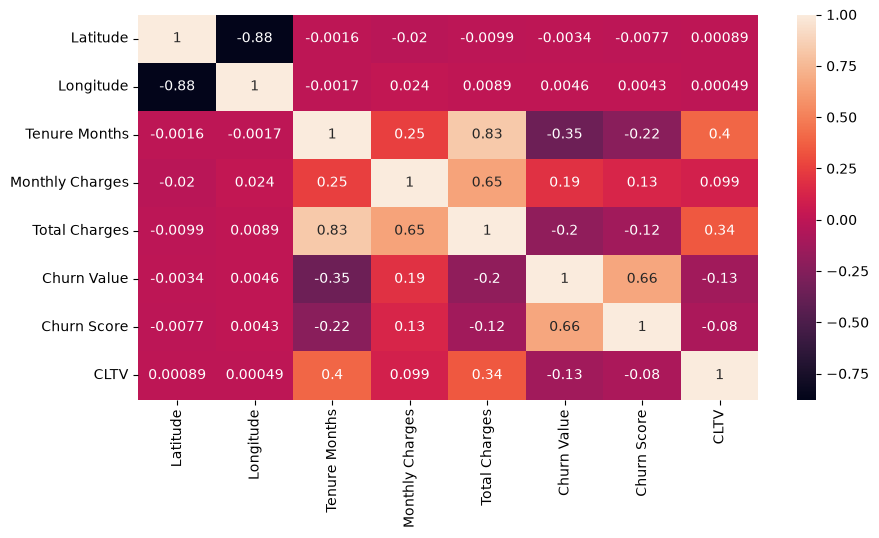

In [58]:
num_attributes_2 = num_attributes.drop('Count', axis = 1)

correlation = num_attributes_2.corr(method = 'pearson')

plt.figure(figsize = (10, 5))
sns.heatmap(correlation, annot = True)

8.2.2 Variáveis Categóricas

In [59]:
cat_attributes_3 = cat_attributes_2.drop('City', axis = 1)
print(cat_attributes_3.columns)   

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')


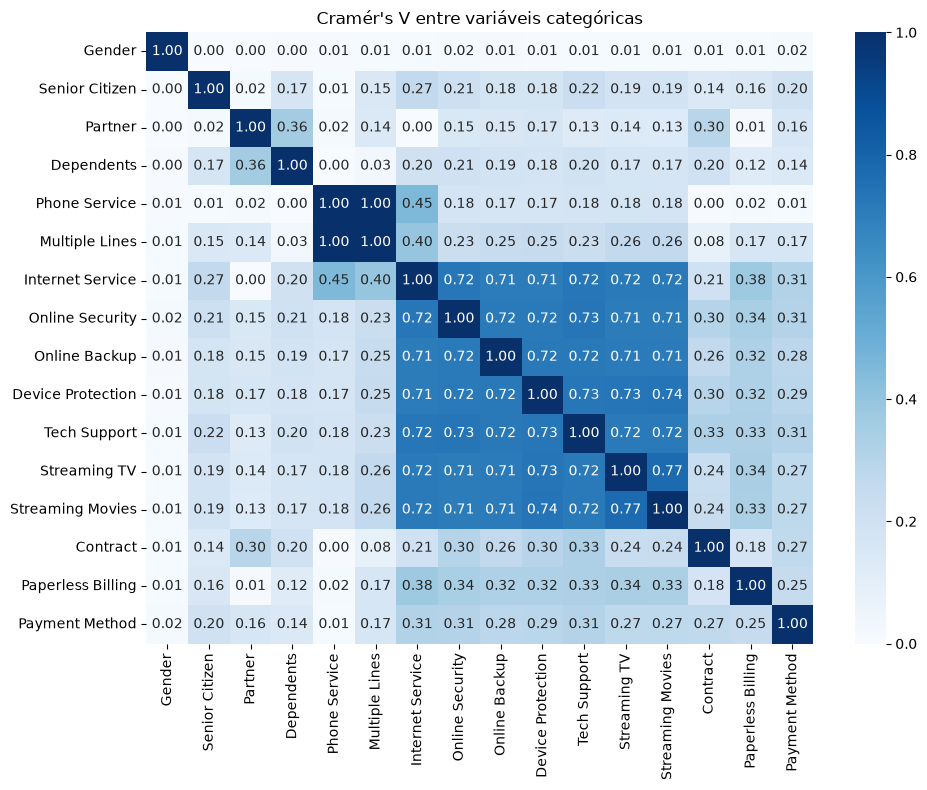

In [60]:
cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
            'Multiple Lines', 'Internet Service', 'Online Security',
            'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
            'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramer_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramer_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title("Cramér's V entre variáveis categóricas")
plt.tight_layout()
plt.show()

# 9.0 Preparação de Dados

In [61]:
#dropar colunas que não vamos utilizar

df4 = df1.drop(['Zip Code', 'CustomerID', 'Count', 'City', 'Country', 'State', 'Lat Long', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'], axis = 1)

df4.head(10).T



,0,1,2,3,4,5,6,7,8,9
Latitude,33.964131,34.059281,34.048013,34.062125,34.039224,34.066367,34.02381,34.066303,34.099869,34.089953
Longitude,-118.272783,-118.30742,-118.293953,-118.315709,-118.266293,-118.309868,-118.156582,-118.435479,-118.326843,-118.294824
Gender,Male,Female,Female,Female,Male,Female,Male,Male,Male,Male
Senior Citizen,No,No,No,No,No,No,Yes,No,No,No
Partner,No,No,No,Yes,No,Yes,No,No,Yes,Yes
Dependents,No,Yes,Yes,Yes,Yes,No,No,No,Yes,No
Tenure Months,2,2,8,28,49,10,1,1,47,1
Phone Service,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No
Multiple Lines,No,No,Yes,Yes,Yes,No,No phone service,No,Yes,No phone service
Internet Service,DSL,Fiber optic,Fiber optic,Fiber optic,Fiber optic,DSL,DSL,No,Fiber optic,DSL


In [62]:
# transformar Male e Female em 0 e 1
df4['Gender'] = df4['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

# transformar Features que são Yes e No em 1 e 0 respectivamente
columns_1 = ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Online Security',
              'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing']

for i in columns_1:
    df4[i] = df4[i].apply(lambda x: 1 if x == 'Yes' else 0)


0.307720149020609


<Axes: >

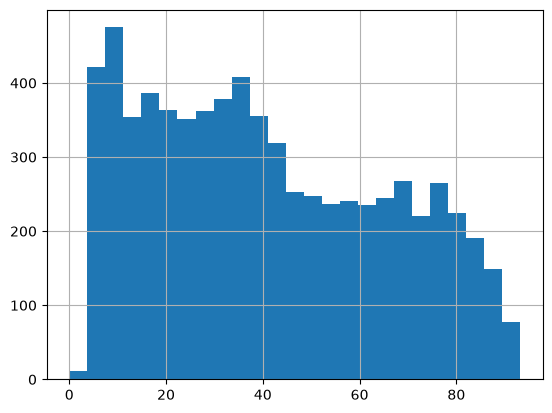

In [63]:
df4.head().T
df4['Total Charges'] = np.sqrt(df4['Total Charges'])
print(df4['Total Charges'].skew())

df4['Total Charges'].hist(bins = 25)

#### Churn Value (desbalanceamento de classe)
#### No     0.73463
#### Yes    0.26537

### 9.1 Train Test Split

In [64]:
y = pd.DataFrame(df1['Churn Value'])

x = df4.copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify = y, random_state = 0, test_size = 0.20)



### 9.2 One Hot Enconder
É uma técnica usada em aprendizado de máquina e estatística para converter variáveis categóricas (como cores, cidades ou estados civis) em um formato numérico que os algoritmos conseguem interpretar

In [65]:
#Internet Service, Payment Method e Conctract, virando em 0 e 1

x_train_encode = pd.get_dummies(x_train, prefix=['Internet Service', 'Contract', 'Payment Method'], columns=['Internet Service', 'Contract', 'Payment Method'], dtype = int)
x_train_encode.head().T

x_test_encode = pd.get_dummies(x_test, prefix=['Internet Service', 'Contract', 'Payment Method'], columns=['Internet Service', 'Contract', 'Payment Method'], dtype = int)
x_test_encode.head().T

,5947,5687,1861,1717,6272
Latitude,33.738543,34.153733,32.811001,40.936285,37.897753
Longitude,-117.785046,-118.593408,-115.152865,-121.572692,-122.279391
Gender,0.000000,1.000000,0.000000,0.000000,0.000000
Senior Citizen,0.000000,0.000000,1.000000,0.000000,0.000000
Partner,0.000000,1.000000,1.000000,1.000000,1.000000
Dependents,0.000000,1.000000,0.000000,0.000000,0.000000
Tenure Months,31.000000,4.000000,1.000000,58.000000,57.000000
Phone Service,1.000000,1.000000,1.000000,1.000000,1.000000
Multiple Lines,0.000000,0.000000,1.000000,1.000000,1.000000
Online Security,0.000000,0.000000,0.000000,1.000000,0.000000


### 9.3 Transformação
- Avaliamos Skew pra ver as curvas tendem a normalidade e quando tem assimetria ou não

- Ela foi feita no DF4, ajustando a skew

<Axes: >

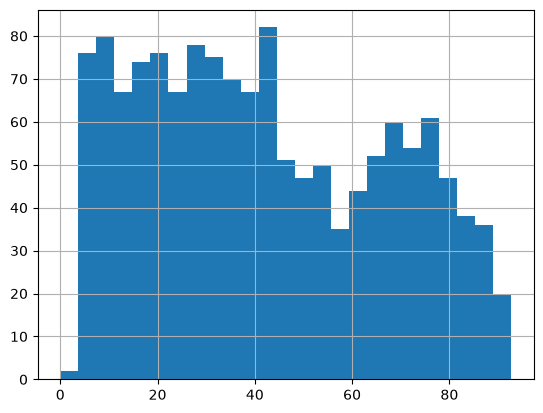

In [66]:
x_test_encode['Total Charges'].hist(bins = 25)

### 9.4 Normalização

### 9.4.1 Rescaling

Trazer a escala de número para médida 0, com desvio padrão reduzido

- StandardScaler -> quando minha skew está cotrolada, entre -0.5 e 0.5
- MinMaxScaler -> quando minha skew estiver controlada e o df não tiver outlier
- RobustScaler -> quando a skew não está muito controlada e o df possuir outlier

In [67]:
columns_scaler = ['Total Charges', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges']

ss = StandardScaler()

for i in columns_scaler:
    x_train_encode[i] = ss.fit_transform(x_train_encode[[i]].values)

    x_test_encode[i] = ss.transform(x_test_encode[[i]].values)

x_train_encode.head().T


,3717,6143,5643,69,2863
Latitude,0.200570,0.149420,-0.879424,-0.908783,1.062229
Longitude,0.024445,-0.830138,0.828463,0.803871,-0.589326
Gender,1.000000,1.000000,0.000000,1.000000,0.000000
Senior Citizen,0.000000,0.000000,0.000000,0.000000,0.000000
Partner,0.000000,0.000000,1.000000,1.000000,1.000000
Dependents,1.000000,0.000000,0.000000,0.000000,0.000000
Tenure Months,0.363266,1.016103,0.404069,-1.105616,1.424126
Phone Service,1.000000,1.000000,1.000000,1.000000,1.000000
Multiple Lines,0.000000,0.000000,1.000000,1.000000,1.000000
Online Security,1.000000,0.000000,0.000000,0.000000,1.000000


# 10.0 Feature Selection

In [68]:
#definicao do modelo e parâmetros de Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=250,
    random_state=42,
    n_jobs=-1
)

#treinamento do modelo
rf.fit(x_train_encode, y_train)

#resultado da importancia de cada coluna
cols = x_train_encode.columns
importancia = rf.feature_importances_

#organizando a visualizacao
importancia_df5 = pd.DataFrame({
    'features': cols,
    'importancia': importancia
})

importancia_df5.sort_values(by = 'importancia', ascending = False)

/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,features,importancia
17,Total Charges,0.131808
6,Tenure Months,0.121919
16,Monthly Charges,0.120687
0,Latitude,0.100896
1,Longitude,0.100465
21,Contract_Month-to-month,0.066979
19,Internet Service_Fiber optic,0.038535
5,Dependents,0.028844
26,Payment Method_Electronic check,0.027574
15,Paperless Billing,0.020736


In [69]:
selecao = SelectFromModel(rf, threshold = 'median', prefit = True)

x_train_final = selecao.transform(x_train_encode) # evidenciando as features escolhidas pelo modelo 
features = x_train_encode.columns[selecao.get_support()] 
print(f'De acordo com modelo, as features escolhidas são: {list(features)}')

/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


De acordo com modelo, as features escolhidas são: ['Latitude', 'Longitude', 'Gender', 'Partner', 'Dependents', 'Tenure Months', 'Online Security', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'Internet Service_Fiber optic', 'Contract_Month-to-month', 'Contract_Two year', 'Payment Method_Electronic check']


In [70]:
features = ['Latitude', 'Longitude', 'Gender', 'Partner', 'Dependents',
       'Tenure Months', 'Online Security', 'Paperless Billing',
       'Monthly Charges', 'Total Charges', 'Internet Service_Fiber optic',
       'Contract_Month-to-month', 'Contract_Two year',
       'Payment Method_Electronic check']

# 11.0 Seleção do Modelo

In [71]:
print(x_train_encode.shape)
print(x_test_encode.shape)

print(y_train.shape)
print(y_test.shape)

(5634, 28)
(1409, 28)
(5634, 1)
(1409, 1)


In [72]:
x_train_final = x_train_encode[features]
x_test_final = x_test_encode[features]

### 11.1 KNN

In [73]:
#definimos modelo e melhor k
melhor_k = np.arange(1, 20, 2)
resultado_melhor_k = []
resultados_accuracy = []

#definir a valiacao de performance
scoring = ["accuracy"]

for i in melhor_k:
    model_knn = KNeighborsClassifier(n_neighbors=i)

    #definicao da crossvalidation
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    #aplicacao da cross validation com os resultados
    resultados_knn = cross_validate(
        model_knn, 
        x_train_final, 
        y_train, 
        cv=cv, 
        scoring=scoring
    )

    for metrica in scoring:
        accuracy = resultados_knn['test_accuracy'].mean()

    resultados_accuracy.append(accuracy)

/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/neighbors/_classificat

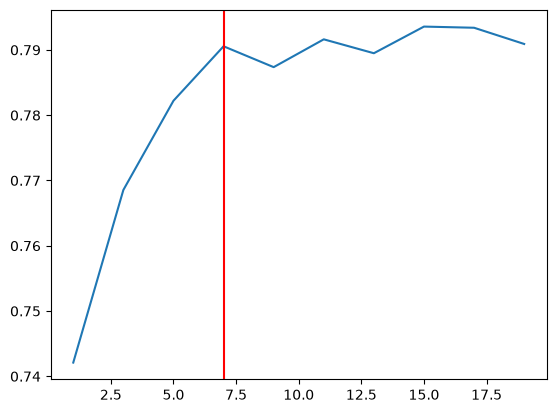

In [74]:
resultados_accuracy

plt.plot(melhor_k, resultados_accuracy)
plt.axvline(x = 7, color = 'red')

In [75]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

#definicao do modelo com k definido 
model_knn = KNeighborsClassifier(n_neighbors=7)

#definicao da crossvalidation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#aplicacao da cross validation com os resultados
resultados_knn = cross_validate(
    model_knn, 
    x_train_final, 
    y_train, 
    cv=cv, 
    scoring=scoring
)

for metrica in scoring:
    print(f'{metrica}: {resultados_knn[f'test_{metrica}'].mean():.4f}')

knn_accuracy = resultados_knn['test_accuracy'].mean()
knn_precision = resultados_knn['test_precision'].mean()
knn_recall = resultados_knn['test_recall'].mean()
knn_f1 = resultados_knn['test_f1'].mean()

/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/neighbors/_classificat

accuracy: 0.7906
precision: 0.6184
recall: 0.5512
f1: 0.5828
roc_auc: 0.8045


/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [76]:
tabela_1 = pd.DataFrame({
    'modelo': 'knn', 
    'accuracy': [knn_accuracy],
    'precision': [knn_precision],
    'recall': [knn_recall],
    'f1': [knn_f1]
})

tabela_1

,modelo,accuracy,precision,recall,f1
0,knn,0.790556,0.61836,0.551171,0.582781


In [77]:
resultados_knn

{'fit_time': array([0.02845931, 0.01226234, 0.01533008, 0.01173425, 0.01643968]),
 'score_time': array([0.14530635, 0.13747954, 0.12459779, 0.14639592, 0.12474537]),
 'test_accuracy': array([0.81011535, 0.77994676, 0.79325643, 0.78793256, 0.78152753]),
 'test_precision': array([0.66283525, 0.59695817, 0.62406015, 0.60869565, 0.59925094]),
 'test_recall': array([0.57859532, 0.52508361, 0.55518395, 0.56187291, 0.53511706]),
 'test_f1': array([0.61785714, 0.55871886, 0.58761062, 0.58434783, 0.56537102]),
 'test_roc_auc': array([0.81258381, 0.78949962, 0.82638384, 0.79639862, 0.79778019])}

### 11.2 Decision Tree

In [78]:
#definimos o melhor max_depth e o modelo
possiveis_md = np.arange(1,11, 2)
dt_accuracy = []

for i in possiveis_md:

    model_dt = DecisionTreeClassifier(max_depth=i)

    #definicao da crossvalidation
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring = ["accuracy"]

    #aplicacao da cross validation com os resultados
    resultados_dt = cross_validate(
        model_dt, 
        x_train_final, 
        y_train, 
        cv=cv, 
        scoring=scoring
    )

    

    for metrica in scoring:
        accuracy = resultados_dt['test_accuracy'].mean()

    dt_accuracy.append(accuracy)

print(dt_accuracy)
melhor_dp_index = np.argmax(dt_accuracy)
melhor_dp = possiveis_md[melhor_dp_index]
melhor_dp


[np.float64(0.7346467539058252), np.float64(0.7873620372544724), np.float64(0.7845226406262559), np.float64(0.7839878896959973), np.float64(0.7689013886502938)]


np.int64(3)

In [82]:
#trabalhando com o melhor max_depth
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

#definicao do modelo
model_dt = DecisionTreeClassifier(max_depth=3, class_weight='balanced')

#definicao da crossvalidation
cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

#aplicacao da cross validation com os resultados
resultados_dt = cross_validate(
        model_dt, 
        x_train_final, 
        y_train, 
        cv=cv, 
        scoring=scoring
    )

resultados_dt = pd.DataFrame(resultados_dt)
resultados_dt

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,0.038326,0.072823,0.739130,0.505330,0.792642,0.617188,0.820729
1,0.017591,0.050514,0.730257,0.494432,0.742475,0.593583,0.784180
2,0.014670,0.056934,0.763975,0.538462,0.772575,0.634615,0.825574
3,0.016559,0.053077,0.783496,0.566586,0.782609,0.657303,0.828062
4,0.019316,0.057805,0.762877,0.537915,0.759197,0.629681,0.820225


In [83]:
tabela_2 = pd.DataFrame({
    'modelo': 'Dt', 
    'accuracy': [resultados_dt['test_accuracy'].mean()],
    'precision': [resultados_dt['test_precision'].mean()],
    'recall': [resultados_dt['test_recall'].mean()],
    'f1': [resultados_dt['test_f1'].mean()]
})

tabela_2

,modelo,accuracy,precision,recall,f1
0,Dt,0.755947,0.528545,0.7699,0.626474


### 11.3 Random Forest

In [ ]:
#tentando achar os melhores parâmetros
n_estimators_range = np.arange(50, 501, 100)   
max_depth_range = np.arange(2, 21, 4)         

resultados = []

for i in n_estimators_range:
    for j in max_depth_range:

        #modelo escolhido
        model_rf = RandomForestClassifier(n_estimators=i, max_depth=j, random_state=0, n_jobs=-1)

        #definicao da crossvalidation
        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        scoring = ["accuracy"]
        
        #aplicacao da cross validation com os resultados
        resultados_rf = cross_validate(
            model_rf, 
            x_train_final, 
            y_train, 
            cv=cv, 
            scoring=scoring
        )
    
        
        accuracy = resultados_rf['test_accuracy'].mean()

        resultados.append({'n_estimators': i, 'max_depth': j, 'accuracy': accuracy})



/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403:

In [ ]:
tabela_rf_preparacao = pd.DataFrame(resultados)

melhor_indice = np.argmax(tabela_rf_preparacao['accuracy'])
melhor_linha = tabela_rf_preparacao.iloc[melhor_indice]
print(melhor_linha)
tabela_rf_preparacao

n_estimators    450.000000
max_depth         6.000000
accuracy          0.803335
Name: 21, dtype: float64


,n_estimators,max_depth,accuracy
0,50,2,0.776356
1,50,6,0.800319
2,50,10,0.799962
3,50,14,0.794104
4,50,18,0.794992
5,150,2,0.772628
6,150,6,0.801915
7,150,10,0.800851
8,150,14,0.800850
9,150,18,0.797123


In [88]:
#trabalhando com o melhor max_depth e n_estimators
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

#modelo escolhido
model_rf = RandomForestClassifier(n_estimators=50, max_depth=6, class_weight='balanced', random_state=0, n_jobs=-1)

#definicao da crossvalidation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#aplicacao da cross validation com os resultados
resultados_rf = cross_validate(
    model_rf, 
    x_train_final, 
    y_train, 
    cv=cv, 
    scoring=scoring
)

resultados_rf = pd.DataFrame(resultados_rf)
resultados_rf

/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403:

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,0.427460,0.164920,0.750665,0.519481,0.802676,0.630749,0.859372
1,0.457132,0.285867,0.749778,0.519101,0.772575,0.620968,0.824409
2,0.498175,0.233255,0.775510,0.551570,0.822742,0.660403,0.866091
3,0.446406,0.190144,0.765750,0.539683,0.795987,0.643243,0.860776
4,0.461700,0.205034,0.769094,0.543430,0.816054,0.652406,0.851322


In [87]:
tabela_3 = pd.DataFrame({
    'modelo': 'Rf', 
    'accuracy': [resultados_rf['test_accuracy'].mean()],
    'precision': [resultados_rf['test_precision'].mean()],
    'recall': [resultados_rf['test_recall'].mean()],
    'f1': [resultados_rf['test_f1'].mean()]
})

tabela_3

,modelo,accuracy,precision,recall,f1
0,Rf,0.76216,0.534653,0.802007,0.641554


### 11.4 XGBoost

In [97]:
#verificando o desbalanceamento
scale_pos_weight = ((y_train == 0).sum() / (y_train == 1).sum())
scale_pos_weight = scale_pos_weight.iloc[0]

#tentando achar os melhores parâmetros
n_estimators_range = np.arange(50, 501, 100)   
max_depth_range = np.arange(2, 21, 4)         

resultados = []

for i in n_estimators_range:
    for j in max_depth_range:

        #modelo escolhido
        model_XGB = XGBClassifier(objective='binary:logistic', n_estimators=i, max_depth=j, random_state=0, learning_rate=0.05, scale_pos_weight=scale_pos_weight, n_jobs=-1)

        #definicao da crossvalidation
        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        scoring = ["accuracy"]
        
        #aplicacao da cross validation com os resultados
        resultados_rf = cross_validate(
            model_XGB, 
            x_train_final, 
            y_train, 
            cv=cv, 
            scoring=scoring
        )
    
        
        accuracy = resultados_rf['test_accuracy'].mean()

        resultados.append({'n_estimators': i, 'max_depth': j, 'accuracy': accuracy})

In [100]:
tabela_XGB_preparacao = pd.DataFrame(resultados)

melhor_indice = np.argmax(tabela_XGB_preparacao['accuracy'])
melhor_linha = tabela_XGB_preparacao.iloc[melhor_indice]
print(melhor_linha)
tabela_XGB_preparacao

n_estimators    250.000000
max_depth        14.000000
accuracy          0.780261
Name: 13, dtype: float64


,n_estimators,max_depth,accuracy
0,50,2,0.742989
1,50,6,0.765708
2,50,10,0.771387
3,50,14,0.772631
4,50,18,0.770502
5,150,2,0.753106
6,150,6,0.767483
7,150,10,0.774759
8,150,14,0.777422
9,150,18,0.779729


In [101]:
#trabalhando com o melhor max_depth e n_estimators
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

#modelo escolhido
model_XGB = XGBClassifier(objective='binary:logistic', n_estimators=50, max_depth=10, random_state=0, learning_rate=0.05, scale_pos_weight=scale_pos_weight, n_jobs=-1)


#definicao da crossvalidation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#aplicacao da cross validation com os resultados
resultados_XGB = cross_validate(
    model_XGB, 
    x_train_final, 
    y_train, 
    cv=cv, 
    scoring=scoring
)

resultados_XGB = pd.DataFrame(resultados_XGB)
resultados_XGB

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,0.860158,0.073794,0.762201,0.539846,0.702341,0.610465,0.845263
1,0.571463,0.076644,0.767524,0.550685,0.672241,0.605422,0.813674
2,0.664222,0.067384,0.781721,0.570292,0.719064,0.636095,0.847073
3,0.577999,0.083991,0.779059,0.568306,0.695652,0.625564,0.845009
4,1.886829,0.140539,0.766430,0.548913,0.675585,0.605697,0.833763


In [102]:
tabela_4 = pd.DataFrame({
    'modelo': 'XGB', 
    'accuracy': [resultados_XGB['test_accuracy'].mean()],
    'precision': [resultados_XGB['test_precision'].mean()],
    'recall': [resultados_XGB['test_recall'].mean()],
    'f1': [resultados_XGB['test_f1'].mean()]
})

tabela_4

,modelo,accuracy,precision,recall,f1
0,XGB,0.771387,0.555608,0.692977,0.616649


### 11.5 Logistic Regression

In [103]:
#modelo escolhido
model_lr = LogisticRegression( class_weight='balanced', random_state=42)

#definicao da crossvalidation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

#aplicacao da cross validation com os resultados
resultados_lr = cross_validate(
    model_lr, 
    x_train_final, 
    y_train, 
    cv=cv, 
    scoring=scoring
)   

resultados_lr = pd.DataFrame(resultados_XGB)
resultados_lr    

/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/utils/validation.py

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,0.860158,0.073794,0.762201,0.539846,0.702341,0.610465,0.845263
1,0.571463,0.076644,0.767524,0.550685,0.672241,0.605422,0.813674
2,0.664222,0.067384,0.781721,0.570292,0.719064,0.636095,0.847073
3,0.577999,0.083991,0.779059,0.568306,0.695652,0.625564,0.845009
4,1.886829,0.140539,0.766430,0.548913,0.675585,0.605697,0.833763


In [105]:
tabela_5 = pd.DataFrame({
    'modelo': 'lr', 
    'accuracy': [resultados_lr['test_accuracy'].mean()],
    'precision': [resultados_lr['test_precision'].mean()],
    'recall': [resultados_lr['test_recall'].mean()],
    'f1': [resultados_lr['test_f1'].mean()]
})

tabela_5

,modelo,accuracy,precision,recall,f1
0,lr,0.771387,0.555608,0.692977,0.616649


# 11.5 Produzindo tabela comparativa dos modelos

In [108]:
tabela_6 = pd.concat([tabela_1, tabela_2, tabela_3, tabela_4, tabela_5], axis=0)
tabela_6.sort_values(by='recall', ascending=False)

,modelo,accuracy,precision,recall,f1
0,Rf,0.762160,0.534653,0.802007,0.641554
0,Dt,0.755947,0.528545,0.769900,0.626474
0,XGB,0.771387,0.555608,0.692977,0.616649
0,lr,0.771387,0.555608,0.692977,0.616649
0,knn,0.790556,0.618360,0.551171,0.582781


# 12.0 Fine Tuning

In [115]:
#ocultar as mensagens do optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 20, 520, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced']),
        'random_state': 42,
        'n_jobs': -1
    }

    modelo = RandomForestClassifier(**params)

    resultados = cross_validate(
        modelo, x_train_final, y_train,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
        n_jobs=-1,
        return_train_score=False
    )

    # guarda todas as métricas no trial, pra recuperar depois
    trial.set_user_attr('accuracy', resultados['test_accuracy'].mean())
    trial.set_user_attr('precision', resultados['test_precision'].mean())
    trial.set_user_attr('recall', resultados['test_recall'].mean())
    trial.set_user_attr('f1', resultados['test_f1'].mean())

    return resultados['test_f1'].mean()  # métrica usada pra guiar a otimização

In [116]:
estudo = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
estudo.optimize(objective, n_trials=50, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.

In [125]:
# ---- Dicionário com todas as métricas do melhor trial ----
melhores_metricas = {
    'accuracy': [estudo.best_trial.user_attrs['accuracy']],
    'precision': [estudo.best_trial.user_attrs['precision']],
    'recall': [estudo.best_trial.user_attrs['recall']],
    'f1': [estudo.best_trial.user_attrs['f1']],
}

melhores_metricas = pd.DataFrame(melhores_metricas)

print('Melhores hiperparâmetros:', estudo.best_params)
melhores_metricas

Melhores hiperparâmetros: {'n_estimators': 20, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 'log2', 'class_weight': 'balanced'}


,accuracy,precision,recall,f1
0,0.765708,0.539261,0.804013,0.645348


# 13.0 Modelo Final

In [128]:
# ---- Treina o modelo final com os melhores hiperparâmetros ----
melhor_modelo = RandomForestClassifier(**estudo.best_params, random_state=42, n_jobs=-1)
melhor_modelo.fit(x_train_final, y_train)

y_pred = melhor_modelo.predict(x_test_final)

print(mt.classification_report(y_test, y_pred))

/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.92      0.76      0.83      1035
           1       0.55      0.82      0.66       374

    accuracy                           0.77      1409
   macro avg       0.74      0.79      0.74      1409
weighted avg       0.82      0.77      0.79      1409



In [129]:
print(mt.confusion_matrix(y_test, y_pred))

[[785 250]
 [ 68 306]]


# 14.0 TUNING E MODELO FINAL 2.0

In [130]:
#ocultar as mensagens do optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 20, 520, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced']),
        'random_state': 42,
        'n_jobs': -1
    }

    modelo = RandomForestClassifier(**params)

    resultados = cross_validate(
        modelo, x_train_final, y_train,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
        n_jobs=-1,
        return_train_score=False
    )

    # guarda todas as métricas no trial, pra recuperar depois
    trial.set_user_attr('accuracy', resultados['test_accuracy'].mean())
    trial.set_user_attr('precision', resultados['test_precision'].mean())
    trial.set_user_attr('recall', resultados['test_recall'].mean())
    trial.set_user_attr('f1', resultados['test_f1'].mean())

    return resultados['test_recall'].mean()  # métrica usada pra guiar a otimização

In [131]:
estudo = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
estudo.optimize(objective, n_trials=50, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.

In [132]:
# ---- Dicionário com todas as métricas do melhor trial ----
melhores_metricas = {
    'accuracy': [estudo.best_trial.user_attrs['accuracy']],
    'precision': [estudo.best_trial.user_attrs['precision']],
    'recall': [estudo.best_trial.user_attrs['recall']],
    'f1': [estudo.best_trial.user_attrs['f1']],
}

melhores_metricas = pd.DataFrame(melhores_metricas)

print('Melhores hiperparâmetros:', estudo.best_params)
melhores_metricas

Melhores hiperparâmetros: {'n_estimators': 20, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'class_weight': 'balanced'}


,accuracy,precision,recall,f1
0,0.725949,0.4906,0.848161,0.621576


In [133]:
# ---- Treina o modelo final com os melhores hiperparâmetros ----
melhor_modelo = RandomForestClassifier(**estudo.best_params, random_state=42, n_jobs=-1)
melhor_modelo.fit(x_train_final, y_train)

y_pred = melhor_modelo.predict(x_test_final)

print(mt.classification_report(y_test, y_pred))

/home/lucas/.pyenv/versions/virtualenv_p_churn/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0       0.93      0.70      0.80      1035
           1       0.51      0.86      0.64       374

    accuracy                           0.74      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.74      0.76      1409



In [134]:
print(mt.confusion_matrix(y_test, y_pred))

[[724 311]
 [ 53 321]]
